In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
#from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
import lightgbm as lgb
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from itertools import product
from sklearn.naive_bayes import GaussianNB
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler


In [2]:
#### Activar segun quien trabaje 
#Marco
Filepath = "C:/Users/user/OneDrive/Documentos/semestres uniandes/Clases 2025-1/Tesis IIND/Solo sector salud/Base analisis exploratorio.csv"
#Paula
#Filepath= "C:/Users/paula/OneDrive/Documentos/10 Semestre/Tesis/base con categorias reducidas2.csv"
df=pd.read_csv(Filepath)
df

,nombre entidad,nit entidad,departamento,ciudad,orden,rama,entidad centralizada,estado contrato,codigo de categoria principal,tipo de contrato,...,fase,precio base,nombre de la unidad de contratación,departamento proveedor,ciudad proveedor,tiempo duracion (dias),duracion_proceso_dias,año_publicacion,porcentaje_pagado,Adicion
0,Otros,Otros,Meta,Villavicencio,Territorial,Ejecutivo,Centralizada,En ejecución,V1.85101600,Prestación de servicios,...,Presentación de oferta,8.273630e+06,Otros,Meta,Otros,38.0,39.0,2024,25-50%,0
1,SUBRED INTEGRADA DE SERVICIO DE SALUD CENTRO O...,900959051,Distrito Capital de Bogotá,Bogotá,Territorial,Ejecutivo,Descentralizada,En ejecución,V1.80111600,Prestación de servicios,...,Presentación de oferta,2.908492e+07,CONTRATACION OPS 2020,Distrito Capital de Bogotá,Bogotá,48.0,53.0,2020,0-25%,1
2,SANTIAGO DE CALI DISTRITO ESPECIAL - SECRETARI...,890399011,Valle del Cauca,Cali,Territorial,Ejecutivo,Centralizada,En ejecución,V1.80111500,Prestación de servicios,...,Presentación de oferta,5.907958e+07,SECRETARIA DISTRITAL DE SALUD DE CALI,Valle del Cauca,Cali,50.0,57.0,2020,0-25%,0
3,SUBRED INTEGRADA DE SERVICIOS DE SALUD NORTE E...,900971006,Distrito Capital de Bogotá,Bogotá,Territorial,Corporación Autónoma,Descentralizada,Activo,V1.85101600,Prestación de servicios,...,Presentación de oferta,3.440880e+07,Otros,Distrito Capital de Bogotá,No Definido,88.0,90.0,2018,0-25%,1
4,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Ejecutivo,Centralizada,En ejecución,Otros,Prestación de servicios,...,Presentación de oferta,7.000000e+07,Grupo de contratación SECOP II,Magdalena,Santa Marta,57.0,60.0,2022,0-25%,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159178,Otros,Otros,Norte de Santander,Tibú,Territorial,Corporación Autónoma,Descentralizada,En ejecución,Otros,Decreto 092 de 2017,...,Presentación de oferta,1.427548e+08,Otros,Norte de Santander,Cúcuta,27.0,30.0,2023,75-100%,0
159179,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Ejecutivo,Centralizada,En ejecución,V1.80111600,Prestación de servicios,...,Presentación de oferta,9.000000e+06,Grupo de contratación SECOP II,Magdalena,Santa Marta,145.0,150.0,2022,0-25%,0
159180,Otros,Otros,Casanare,Yopal,Territorial,Ejecutivo,Descentralizada,En ejecución,V1.80111701,Prestación de servicios,...,Presentación de oferta,1.800000e+06,Otros,Casanare,Otros,30.0,30.0,2023,0-25%,0
159181,Otros,899999239,Nariño,No Definido,Nacional,Ejecutivo,Centralizada,En ejecución,V1.80111600,Prestación de servicios,...,Presentación de oferta,1.568828e+07,Otros,Nariño,Otros,175.0,173.0,2024,0-25%,0


In [3]:
df.columns

Index(['nombre entidad', 'nit entidad', 'departamento', 'ciudad', 'orden',
       'rama', 'entidad centralizada', 'estado contrato',
       'codigo de categoria principal', 'tipo de contrato',
       'modalidad de contratacion', 'justificacion modalidad de contratacion',
       'condiciones de entrega', 'es pyme', 'liquidación',
       'origen de los recursos', 'destino gasto', 'valor del contrato',
       'valor pendiente de pago', 'estado bpin', 'anno bpin',
       'el contrato puede ser prorrogado', 'fase', 'precio base',
       'nombre de la unidad de contratación', 'departamento proveedor',
       'ciudad proveedor', 'tiempo duracion (dias)', 'duracion_proceso_dias',
       'año_publicacion', 'porcentaje_pagado', 'Adicion'],
      dtype='object')

In [4]:
# Filtrar contratos con adición
contratos_adicionados = df[df['Adicion'] == 1]

# Calcular el promedio del valor del contrato
promedio_valor_contrato = contratos_adicionados['valor del contrato'].mean()

# Calcular el 20% del promedio
veinte_por_ciento = promedio_valor_contrato * 0.2

# Mostrar resultados
print(f"Promedio del valor del contrato: {promedio_valor_contrato}")
print(f"20% del promedio: {veinte_por_ciento}")

Promedio del valor del contrato: 36813561.24579481
20% del promedio: 7362712.249158963


In [5]:
#salario equipo revision
salario_equipo_revision_bajo =  3_107_410.69
salario_equipo_revision_medio =  5_340_558.54
salario_equipo_revision_alto =  8_581_298.43
print(f"Salario equipo revision bajo: {salario_equipo_revision_bajo}")
print(f"Salario equipo revision medio: {salario_equipo_revision_medio}")    
print(f"Salario equipo revision alto: {salario_equipo_revision_alto}") 



Salario equipo revision bajo: 3107410.69
Salario equipo revision medio: 5340558.54
Salario equipo revision alto: 8581298.43


División de categoricas y númericas

In [6]:
# Seleccionar columnas categóricas, enteras y de punto flotante
catcols = df.select_dtypes(exclude=['int64', 'float64']).columns
intcols = df.select_dtypes(include=['int64']).columns
floatcols = df.select_dtypes(include=['float64']).columns



In [7]:
catcols

Index(['nombre entidad', 'nit entidad', 'departamento', 'ciudad', 'orden',
       'rama', 'entidad centralizada', 'estado contrato',
       'codigo de categoria principal', 'tipo de contrato',
       'modalidad de contratacion', 'justificacion modalidad de contratacion',
       'condiciones de entrega', 'es pyme', 'liquidación',
       'origen de los recursos', 'destino gasto', 'estado bpin', 'anno bpin',
       'el contrato puede ser prorrogado', 'fase',
       'nombre de la unidad de contratación', 'departamento proveedor',
       'ciudad proveedor', 'porcentaje_pagado'],
      dtype='object')

In [8]:
# Contar el número de categorías únicas por cada variable categórica
category_counts = df[catcols].nunique()

# Mostrar los resultados
print("Número de categorías por variable categórica:")
print(category_counts)

Número de categorías por variable categórica:
nombre entidad                              12
nit entidad                                 12
departamento                                18
ciudad                                     169
orden                                        3
rama                                         3
entidad centralizada                         2
estado contrato                              2
codigo de categoria principal               12
tipo de contrato                             4
modalidad de contratacion                    6
justificacion modalidad de contratacion      5
condiciones de entrega                       5
es pyme                                      2
liquidación                                  2
origen de los recursos                       2
destino gasto                                3
estado bpin                                  2
anno bpin                                    9
el contrato puede ser prorrogado             2
fase          

In [9]:
# Codificación de variables categóricas
df_dummies = pd.get_dummies(df, columns=catcols, dtype=int, drop_first=True)

# Identificar las categorías excluidas
excluded_categories = {}
for col in catcols:
    unique_values = df[col].unique()
    excluded_categories[col] = unique_values[0]  # La primera categoría es la excluida

# Mostrar las categorías excluidas
print("Categorías excluidas por multicolinealidad:")
for col, category in excluded_categories.items():
    print(f"{col}: {category}")

# Visualizar el DataFrame con variables dummies
df_dummies


Categorías excluidas por multicolinealidad:
nombre entidad: Otros
nit entidad: Otros
departamento: Meta
ciudad: Villavicencio
orden: Territorial
rama: Ejecutivo
entidad centralizada: Centralizada
estado contrato: En ejecución
codigo de categoria principal: V1.85101600
tipo de contrato: Prestación de servicios
modalidad de contratacion: Contratación régimen especial
justificacion modalidad de contratacion: Regla aplicable
condiciones de entrega: A convenir
es pyme: No
liquidación: No
origen de los recursos: Recursos Propios
destino gasto: Funcionamiento
estado bpin: No Válido
anno bpin: No D
el contrato puede ser prorrogado: No
fase: Presentación de oferta
nombre de la unidad de contratación: Otros
departamento proveedor: Meta
ciudad proveedor: Otros
porcentaje_pagado: 25-50%


,valor del contrato,valor pendiente de pago,precio base,tiempo duracion (dias),duracion_proceso_dias,año_publicacion,Adicion,nombre entidad_ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARRENECHE,nombre entidad_FONDO FINANCIERO DISTRITAL DE SALUD.,nombre entidad_ICBF REGIONAL BOGOTA,...,ciudad proveedor_Manizales,ciudad proveedor_Medellín,ciudad proveedor_No Definido,ciudad proveedor_Otros,ciudad proveedor_Santa Marta,ciudad proveedor_Soacha,ciudad proveedor_Villavicencio,porcentaje_pagado_25-50%,porcentaje_pagado_50-75%,porcentaje_pagado_75-100%
0,8273630.0,4136815.0,8.273630e+06,38.0,39.0,2024,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
1,5272122.0,5272122.0,2.908492e+07,48.0,53.0,2020,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,8439940.0,8439940.0,5.907958e+07,50.0,57.0,2020,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,34408800.0,34408800.0,3.440880e+07,88.0,90.0,2018,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,70000000.0,70000000.0,7.000000e+07,57.0,60.0,2022,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159178,142754780.0,0.0,1.427548e+08,27.0,30.0,2023,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
159179,9000000.0,9000000.0,9.000000e+06,145.0,150.0,2022,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
159180,1800000.0,1800000.0,1.800000e+06,30.0,30.0,2023,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
159181,15688277.0,15688277.0,1.568828e+07,175.0,173.0,2024,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [10]:
# Definir las características (X) y la variable objetivo (y)
X = df_dummies.drop('Adicion', axis=1)  # 'Adicion' es la variable objetivo
y = df_dummies['Adicion']



In [11]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [12]:
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]


## XGBoost

### Salario bajo

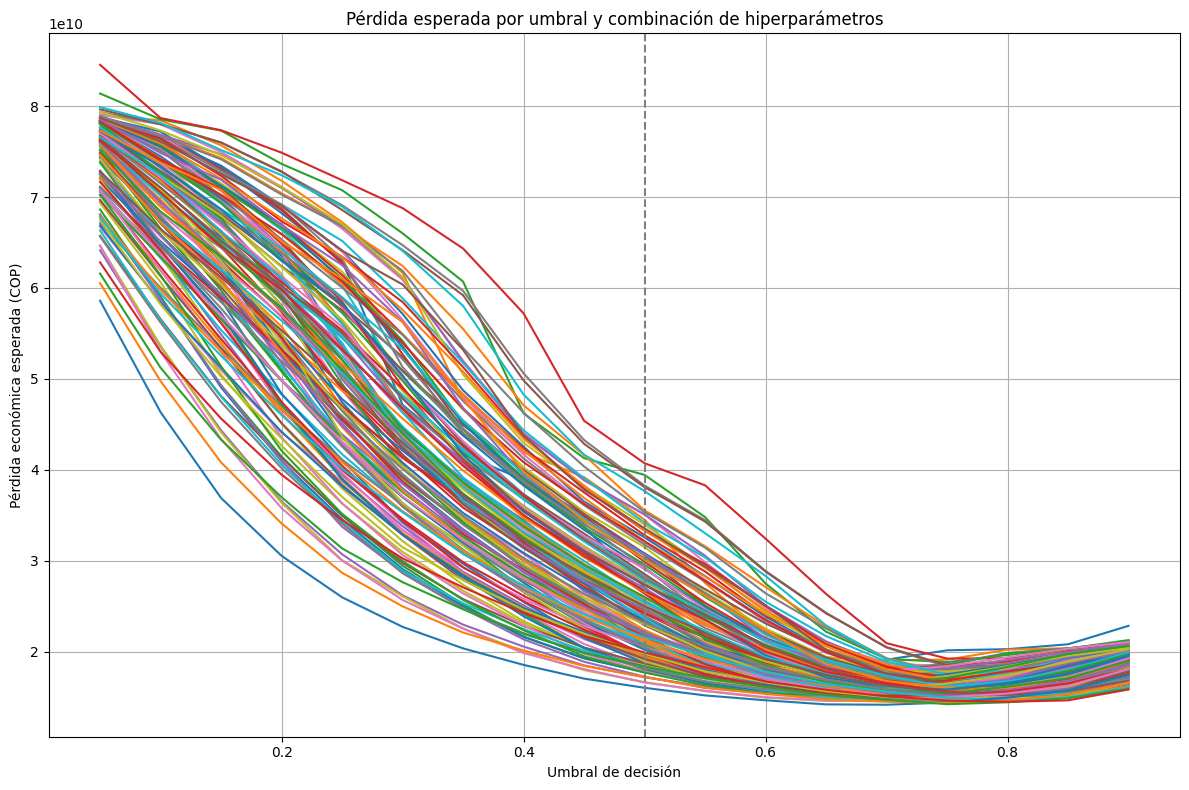

In [13]:
# Hiperparámetros a combinar (ya sin subsample ni colsample_bytree)
max_depths = [4, 6, 8,10]
learning_rates = [0.05, 0.1, 0.15]
n_estimators_list = [100, 200,300]
scale_pos_weights = [7,9, 11, 13]

# Costos ajustables
costo_FN = veinte_por_ciento
costo_FP = salario_equipo_revision_bajo

# Umbrales a explorar
umbrales = np.arange(0.05, 0.95, 0.05)
resultados = {}

# Generar combinaciones
combinaciones = list(product(max_depths, learning_rates, n_estimators_list, scale_pos_weights))

# Entrenar y calcular pérdidas
for max_depth, lr, n_estimators, spw in combinaciones:
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=lr,
        scale_pos_weight=spw,
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0
    )

    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    perdidas = []
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        perdida = (fn * costo_FN) + (fp * costo_FP)
        perdidas.append(perdida)

    etiqueta = f"depth={max_depth}, lr={lr}, est={n_estimators}, spw={spw}"
    resultados[etiqueta] = perdidas

# Graficar las curvas de pérdida
plt.figure(figsize=(12, 8))
for nombre, perdidas in resultados.items():
    plt.plot(umbrales, perdidas, label=nombre)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada por umbral y combinación de hiperparámetros")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.grid(True)
plt.tight_layout()
plt.show()

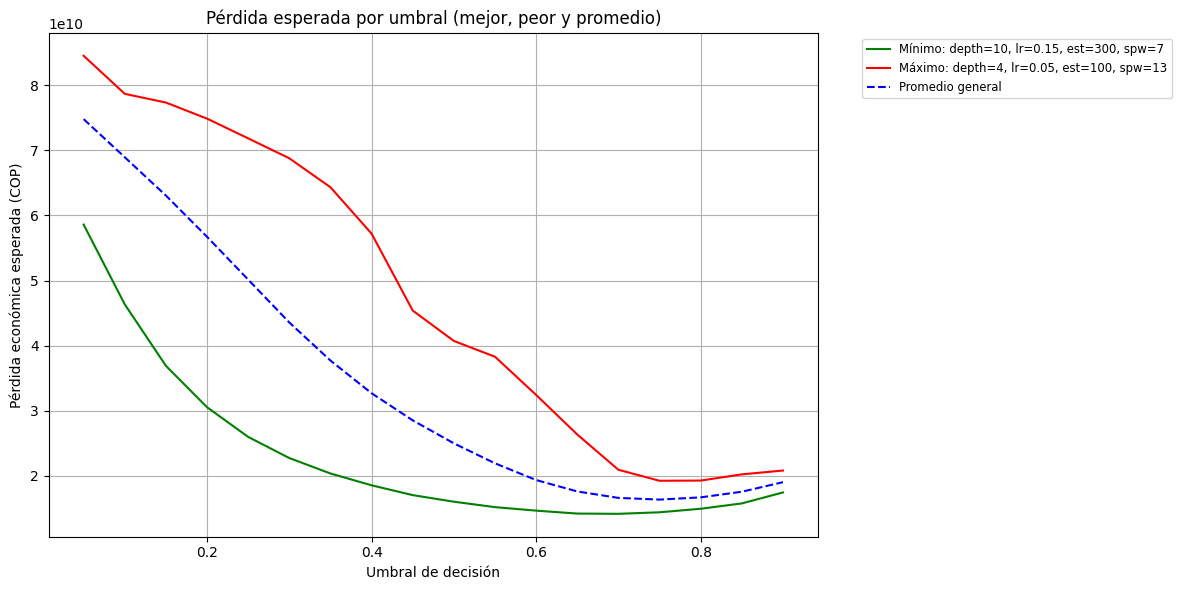

In [23]:

# Asegúrate de usar los mismos umbrales que usaste al entrenar
umbrales = np.arange(0.05, 0.95, 0.05)  # Esto da 18 puntos

# Paso 1: calcular la pérdida total por combinación
suma_por_modelo = {k: sum(v) for k, v in resultados.items()}

# Paso 2: identificar modelo con menor y mayor pérdida total
mejor_modelo = min(suma_por_modelo, key=suma_por_modelo.get)
peor_modelo = max(suma_por_modelo, key=suma_por_modelo.get)

# Paso 3: calcular promedio de pérdidas por umbral (punto a punto)
promedio_por_umbral = np.mean(np.array(list(resultados.values())), axis=0)

# Paso 4: graficar
plt.figure(figsize=(12, 6))

plt.plot(umbrales, resultados[mejor_modelo], 'g-', label=f"Mínimo: {mejor_modelo}")
plt.plot(umbrales, resultados[peor_modelo], 'r-', label=f"Máximo: {peor_modelo}")
plt.plot(umbrales, promedio_por_umbral, 'b--', label="Promedio general")

plt.title("Pérdida esperada por umbral (mejor, peor y promedio)")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()



In [37]:
# Encontrar la combinación y umbral con menor pérdida
mejor_combinacion = None
mejor_umbral = None
mejor_perdida = float('inf')

for nombre, perdidas in resultados.items():
    idx_min = np.argmin(perdidas)
    if perdidas[idx_min] < mejor_perdida:
        mejor_perdida = perdidas[idx_min]
        mejor_combinacion = nombre
        mejor_umbral = umbrales[idx_min]

# Mostrar resultado óptimo
print("Mejor combinación encontrada:")
print(f"Parámetros: {mejor_combinacion}")
print(f"Umbral óptimo: {mejor_umbral:.2f}")
print(f"Pérdida mínima estimada: ${mejor_perdida:,.0f} COP")


Mejor combinación encontrada:
Parámetros: depth=10, lr=0.15, est=300, spw=11
Umbral óptimo: 0.90
Pérdida mínima estimada: $18,287,728,347 COP


In [ ]:
# Crear y entrenar el modelo XGBoost
model_XGdef = XGBClassifier(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.15,
    scale_pos_weight=11,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=1
)

model_XGdef.fit(X_train, y_train)

# Obtener predicciones como probabilidades
y_proba_XGdef = model_XGdef.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
umbral = 0.9
y_pred_XG_customedef = (y_proba_XGdef >= umbral).astype(int)


# Evaluación del modelo
print(f"\n Evaluación del modelo XGBoost con umbral = {umbral}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_XG_customedef, target_names=['No Adición', 'Adición']))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_XG_customedef))

# Definir costos
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = salario_equipo_revision_bajo    # Revisar innecesariamente un contrato

# Obtener métricas de la matriz de confusión
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_XG_customedef).ravel()

# Calcular pérdida económica total
perdida_total = (fn * costo_FN) + (fp * costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbral}: ${perdida_total:,.0f} COP")
print(fn,fp)

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:34:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Evaluación del modelo XGBoost con umbral = 0.7

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       0.95      0.96      0.95     28350
     Adición       0.64      0.59      0.61      3486

    accuracy                           0.92     31836
   macro avg       0.79      0.77      0.78     31836
weighted avg       0.92      0.92      0.92     31836

Matriz de confusión:
[[27172  1178]
 [ 1426  2060]]

Costo total estimado con umbral = 0.7: $14,159,757,460 COP
1426 1178


In [26]:
Costoporcontrato=perdida_total/len(X_test)
Costoporcontrato

444771.87649581226

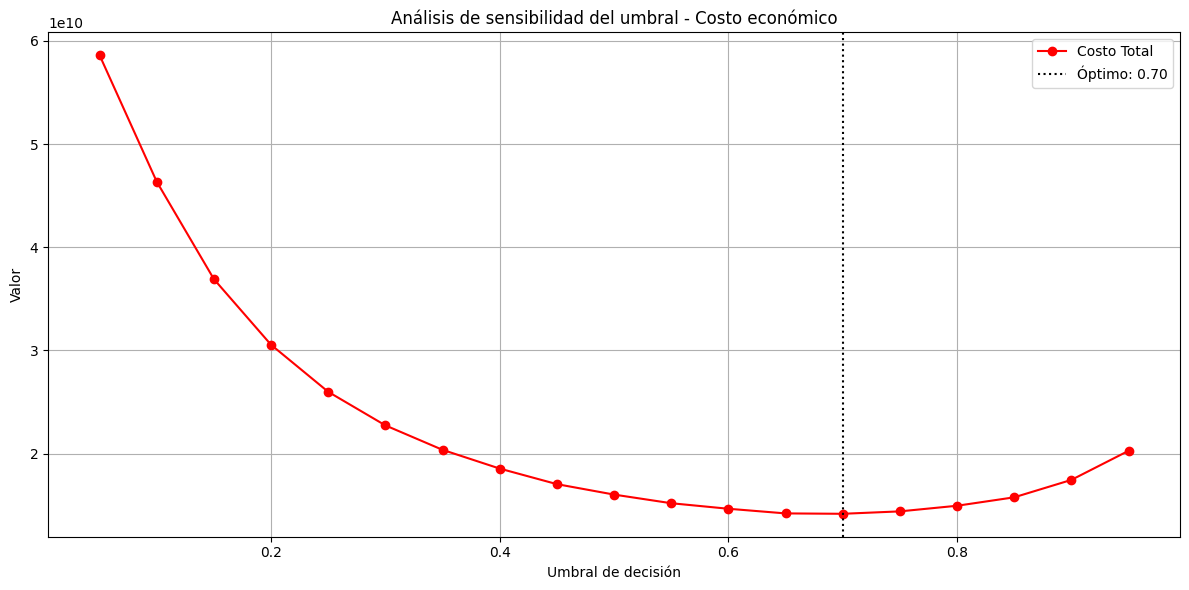

In [27]:
# Umbrales a probar
umbrales = np.arange(0.05, 0.96, 0.05)

# Resultados a guardar
falsos_positivos = []
falsos_negativos = []
costos = []

# Costos definidos
costo_FN = veinte_por_ciento
costo_FP = salario_equipo_revision_bajo

# Calcular pérdida para cada umbral
for umbral_i in umbrales:
    y_pred_temp = (y_proba_XGdef >= umbral_i).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()

    costo_total = (fn * costo_FN) + (fp * costo_FP)
    falsos_positivos.append(fp)
    falsos_negativos.append(fn)
    costos.append(costo_total)

# Encontrar umbral óptimo
idx_optimo = np.argmin(costos)
umbral_optimo = umbrales[idx_optimo]
costo_minimo = costos[idx_optimo]

# Graficar resultados
plt.figure(figsize=(12, 6))
plt.plot(umbrales, costos, label='Costo Total', color='red', marker='o')

plt.axvline(x=umbral_optimo, linestyle=':', color='black', label=f'Óptimo: {umbral_optimo:.2f}')
plt.title("Análisis de sensibilidad del umbral - Costo económico")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [28]:
# Lista de umbrales con paso de 1%
umbrales = np.arange(0.05, 0.95, 0.01)

costos = []
fn_list = []
fp_list = []

# Evaluar costo por cada umbral
for umbral in umbrales:
    y_pred_umbral = (y_proba_XGdef >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_umbral).ravel()
    costo = (fn * costo_FN) + (fp * costo_FP)
    costos.append(costo)
    fn_list.append(fn)
    fp_list.append(fp)

# Calcular sensibilidad: cambio porcentual del costo entre umbrales
cambios = [0]  # no hay cambio para el primero
for i in range(1, len(costos)):
    cambio = (costos[i] - costos[i-1]) / costos[i-1] * 100
    cambios.append(cambio)

# Mostrar resumen tabular de los principales cambios
import pandas as pd

tabla_sensibilidad = pd.DataFrame({
    'Umbral': umbrales,
    'Costo Total': costos,
    'Cambio % vs anterior': cambios,
    'FN': fn_list,
    'FP': fp_list
})

# Mostrar top cambios fuertes
pd.set_option('display.float_format', '{:,.2f}'.format)
display(tabla_sensibilidad.head(10))  # o .tail(10) o todo

# Sensibilidad media (absoluta)
sensibilidad_baja = np.mean(np.abs(tabla_sensibilidad['Cambio % vs anterior'][1:]))  # sin el primero
print(f"Sensibilidad baja: {sensibilidad_baja:.2f}% por cada 1% de cambio en el umbral")


,Umbral,Costo Total,Cambio % vs anterior,FN,FP
0,0.05,"58,603,226,671.36",0.00,79,18672
1,0.06,"55,801,884,433.45",-4.78,102,17716
2,0.07,"53,031,280,040.53",-4.97,122,16777
3,0.08,"50,774,882,564.24",-4.25,146,15994
4,0.09,"48,698,714,907.97",-4.09,170,15269
5,0.10,"46,343,691,918.55",-4.84,192,14459
6,0.11,"44,199,833,750.93",-4.63,222,13698
7,0.12,"42,171,425,145.88",-4.59,247,12986
8,0.13,"40,411,877,118.07",-4.17,268,12370
9,0.14,"38,645,638,901.85",-4.37,294,11740


Sensibilidad baja: 1.94% por cada 1% de cambio en el umbral


### Salario medio

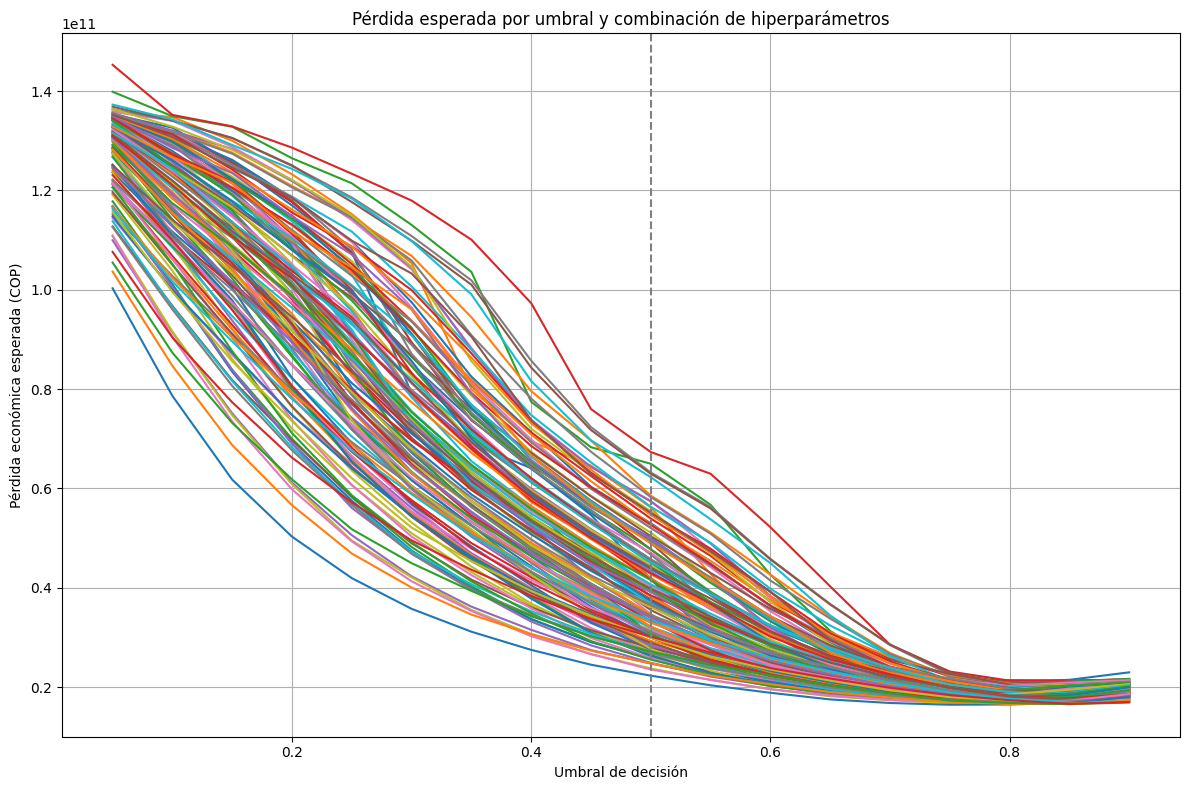

In [29]:
# Hiperparámetros a combinar (ya sin subsample ni colsample_bytree)
max_depths = [4, 6, 8,10]
learning_rates = [0.05, 0.1, 0.15]
n_estimators_list = [100, 200,300]
scale_pos_weights = [7,9, 11, 13]

# Costos ajustables
costo_FN = veinte_por_ciento
costo_FP = salario_equipo_revision_medio

# Umbrales a explorar
umbrales = np.arange(0.05, 0.95, 0.05)
resultados = {}

# Generar combinaciones
combinaciones = list(product(max_depths, learning_rates, n_estimators_list, scale_pos_weights))

# Entrenar y calcular pérdidas
for max_depth, lr, n_estimators, spw in combinaciones:
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=lr,
        scale_pos_weight=spw,
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0
    )

    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    perdidas = []
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        perdida = (fn * costo_FN) + (fp * costo_FP)
        perdidas.append(perdida)

    etiqueta = f"depth={max_depth}, lr={lr}, est={n_estimators}, spw={spw}"
    resultados[etiqueta] = perdidas

# Graficar las curvas de pérdida
plt.figure(figsize=(12, 8))
for nombre, perdidas in resultados.items():
    plt.plot(umbrales, perdidas, label=nombre)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada por umbral y combinación de hiperparámetros")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.grid(True)
plt.tight_layout()
plt.show()

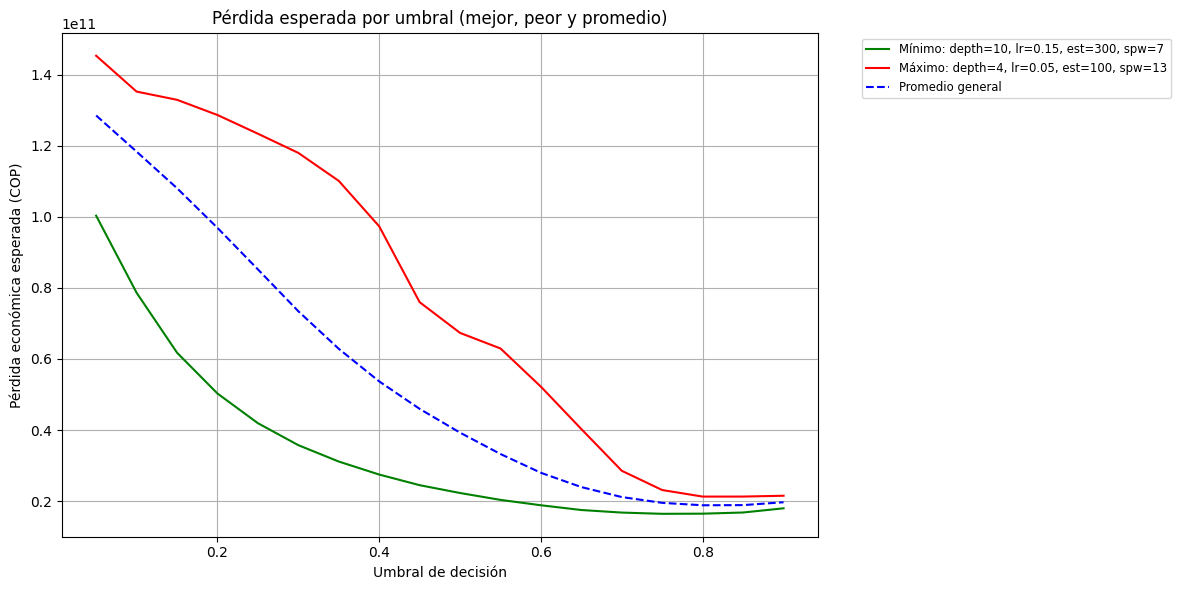

In [30]:
# Asegúrate de usar los mismos umbrales que usaste al entrenar
umbrales = np.arange(0.05, 0.95, 0.05)  # Esto da 18 puntos

# Paso 1: calcular la pérdida total por combinación
suma_por_modelo = {k: sum(v) for k, v in resultados.items()}

# Paso 2: identificar modelo con menor y mayor pérdida total
mejor_modelo = min(suma_por_modelo, key=suma_por_modelo.get)
peor_modelo = max(suma_por_modelo, key=suma_por_modelo.get)

# Paso 3: calcular promedio de pérdidas por umbral (punto a punto)
promedio_por_umbral = np.mean(np.array(list(resultados.values())), axis=0)

# Paso 4: graficar
plt.figure(figsize=(12, 6))

plt.plot(umbrales, resultados[mejor_modelo], 'g-', label=f"Mínimo: {mejor_modelo}")
plt.plot(umbrales, resultados[peor_modelo], 'r-', label=f"Máximo: {peor_modelo}")
plt.plot(umbrales, promedio_por_umbral, 'b--', label="Promedio general")

plt.title("Pérdida esperada por umbral (mejor, peor y promedio)")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [31]:
# Encontrar la combinación y umbral con menor pérdida
mejor_combinacion = None
mejor_umbral = None
mejor_perdida = float('inf')

for nombre, perdidas in resultados.items():
    idx_min = np.argmin(perdidas)
    if perdidas[idx_min] < mejor_perdida:
        mejor_perdida = perdidas[idx_min]
        mejor_combinacion = nombre
        mejor_umbral = umbrales[idx_min]

# Mostrar resultado óptimo
print("Mejor combinación encontrada:")
print(f"Parámetros: {mejor_combinacion}")
print(f"Umbral óptimo: {mejor_umbral:.2f}")
print(f"Pérdida mínima estimada: ${mejor_perdida:,.0f} COP")


Mejor combinación encontrada:
Parámetros: depth=10, lr=0.15, est=300, spw=7
Umbral óptimo: 0.75
Pérdida mínima estimada: $16,442,024,988 COP


In [32]:
# Crear y entrenar el modelo XGBoost
model_XGdef = XGBClassifier(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.15,
    scale_pos_weight=7,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=1
)

model_XGdef.fit(X_train, y_train)

# Obtener predicciones como probabilidades
y_proba_XGdef = model_XGdef.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
umbral = 0.75
y_pred_XG_customedef = (y_proba_XGdef >= umbral).astype(int)


# Evaluación del modelo
print(f"\n Evaluación del modelo XGBoost con umbral = {umbral}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_XG_customedef, target_names=['No Adición', 'Adición']))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_XG_customedef))

# Definir costos
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = salario_equipo_revision_medio    # Revisar innecesariamente un contrato

# Obtener métricas de la matriz de confusión
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_XG_customedef).ravel()

# Calcular pérdida económica total
perdida_total = (fn * costo_FN) + (fp * costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbral}: ${perdida_total:,.0f} COP")
print(fn,fp)

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:44:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Evaluación del modelo XGBoost con umbral = 0.75

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       0.95      0.97      0.96     28350
     Adición       0.68      0.55      0.61      3486

    accuracy                           0.92     31836
   macro avg       0.81      0.76      0.78     31836
weighted avg       0.92      0.92      0.92     31836

Matriz de confusión:
[[27433   917]
 [ 1568  1918]]

Costo total estimado con umbral = 0.75: $16,442,024,988 COP
1568 917


In [33]:
Costoporcontrato=perdida_total/len(X_test)
Costoporcontrato

516460.13908346696

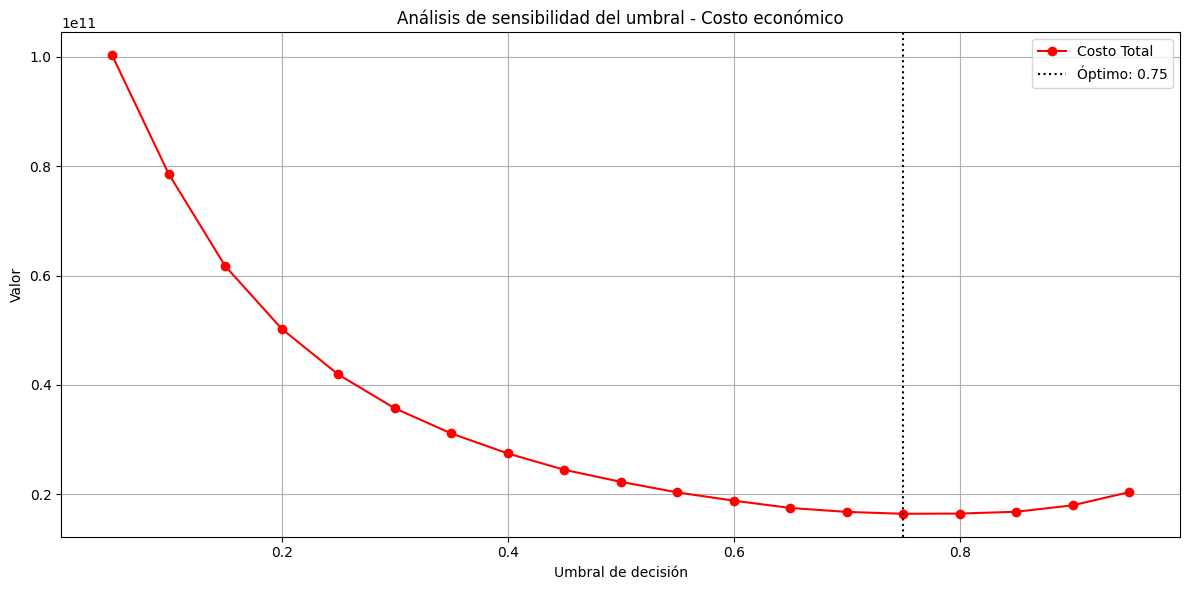

In [34]:
# Umbrales a probar
umbrales = np.arange(0.05, 0.96, 0.05)

# Resultados a guardar
falsos_positivos = []
falsos_negativos = []
costos = []

# Costos definidos
costo_FN = veinte_por_ciento
costo_FP = salario_equipo_revision_medio

# Calcular pérdida para cada umbral
for umbral_i in umbrales:
    y_pred_temp = (y_proba_XGdef >= umbral_i).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()

    costo_total = (fn * costo_FN) + (fp * costo_FP)
    falsos_positivos.append(fp)
    falsos_negativos.append(fn)
    costos.append(costo_total)

# Encontrar umbral óptimo
idx_optimo = np.argmin(costos)
umbral_optimo = umbrales[idx_optimo]
costo_minimo = costos[idx_optimo]

# Graficar resultados
plt.figure(figsize=(12, 6))
plt.plot(umbrales, costos, label='Costo Total', color='red', marker='o')

plt.axvline(x=umbral_optimo, linestyle=':', color='black', label=f'Óptimo: {umbral_optimo:.2f}')
plt.title("Análisis de sensibilidad del umbral - Costo económico")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [35]:
# Lista de umbrales con paso de 1%
umbrales = np.arange(0.05, 0.95, 0.01)

costos = []
fn_list = []
fp_list = []

# Evaluar costo por cada umbral
for umbral in umbrales:
    y_pred_umbral = (y_proba_XGdef >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_umbral).ravel()
    costo = (fn * costo_FN) + (fp * costo_FP)
    costos.append(costo)
    fn_list.append(fn)
    fp_list.append(fp)

# Calcular sensibilidad: cambio porcentual del costo entre umbrales
cambios = [0]  # no hay cambio para el primero
for i in range(1, len(costos)):
    cambio = (costos[i] - costos[i-1]) / costos[i-1] * 100
    cambios.append(cambio)

# Mostrar resumen tabular de los principales cambios
import pandas as pd

tabla_sensibilidad = pd.DataFrame({
    'Umbral': umbrales,
    'Costo Total': costos,
    'Cambio % vs anterior': cambios,
    'FN': fn_list,
    'FP': fp_list
})

# Mostrar top cambios fuertes
pd.set_option('display.float_format', '{:,.2f}'.format)
display(tabla_sensibilidad.head(10))  # o .tail(10) o todo

# Sensibilidad media (absoluta)
sensibilidad_media = np.mean(np.abs(tabla_sensibilidad['Cambio % vs anterior'][1:]))  # sin el primero
print(f"Sensibilidad media: {sensibilidad_media:.2f}% por cada 1% de cambio en el umbral")


,Umbral,Costo Total,Cambio % vs anterior,FN,FP
0,0.05,"100,300,563,326.56",0.00,79,18672
1,0.06,"95,364,331,744.05",-4.92,102,17716
2,0.07,"90,496,801,519.98",-5.10,122,16777
3,0.08,"86,491,849,277.14",-4.43,146,15994
4,0.09,"82,796,649,429.62",-4.27,170,15269
5,0.10,"78,632,776,681.70",-5.03,192,14459
6,0.11,"74,789,493,000.23",-4.89,222,13698
7,0.12,"71,171,083,125.98",-4.84,247,12986
8,0.13,"68,035,916,022.57",-4.41,268,12370
9,0.14,"64,862,794,660.85",-4.66,294,11740


Sensibilidad media: 2.21% por cada 1% de cambio en el umbral


### Salario Alto

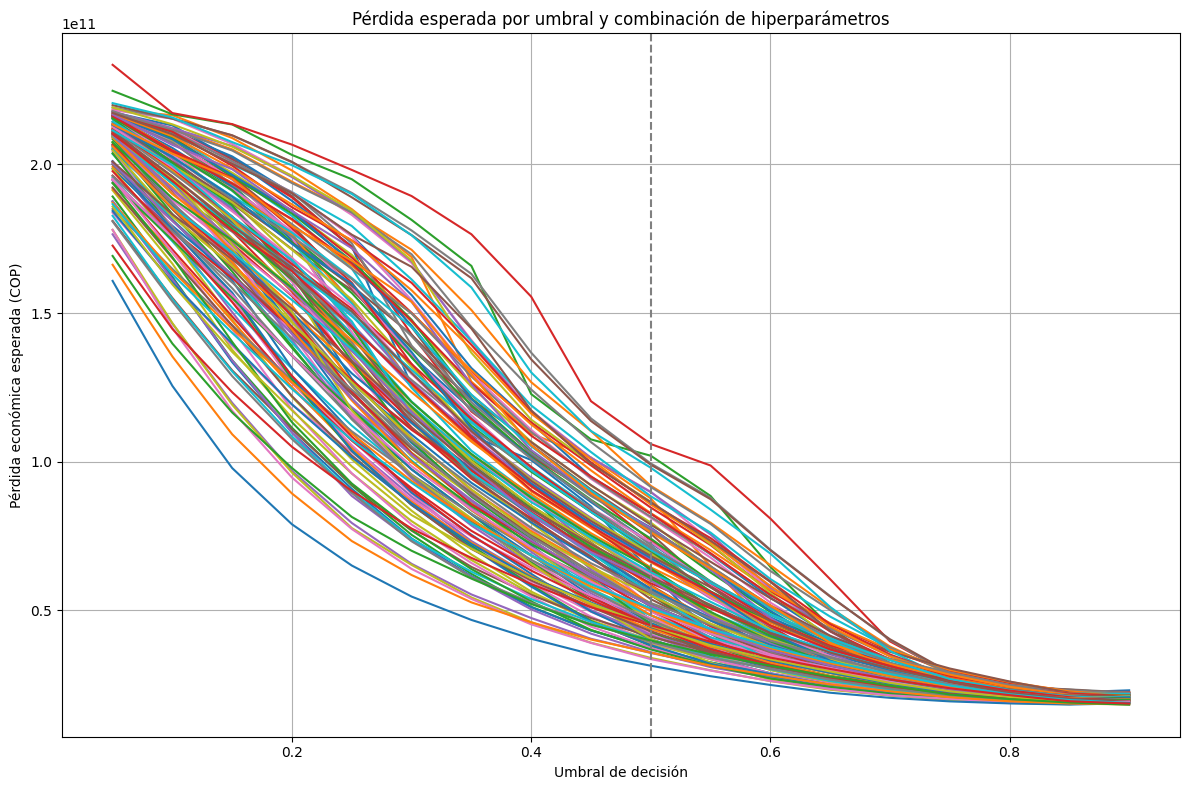

In [36]:
# Hiperparámetros a combinar (ya sin subsample ni colsample_bytree)
max_depths = [4, 6, 8,10]
learning_rates = [0.05, 0.1, 0.15]
n_estimators_list = [100, 200,300]
scale_pos_weights = [7,9, 11, 13]

# Costos ajustables
costo_FN = veinte_por_ciento
costo_FP = salario_equipo_revision_alto

# Umbrales a explorar
umbrales = np.arange(0.05, 0.95, 0.05)
resultados = {}

# Generar combinaciones
combinaciones = list(product(max_depths, learning_rates, n_estimators_list, scale_pos_weights))

# Entrenar y calcular pérdidas
for max_depth, lr, n_estimators, spw in combinaciones:
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=lr,
        scale_pos_weight=spw,
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0
    )

    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    perdidas = []
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        perdida = (fn * costo_FN) + (fp * costo_FP)
        perdidas.append(perdida)

    etiqueta = f"depth={max_depth}, lr={lr}, est={n_estimators}, spw={spw}"
    resultados[etiqueta] = perdidas

# Graficar las curvas de pérdida
plt.figure(figsize=(12, 8))
for nombre, perdidas in resultados.items():
    plt.plot(umbrales, perdidas, label=nombre)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada por umbral y combinación de hiperparámetros")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.grid(True)
plt.tight_layout()
plt.show()

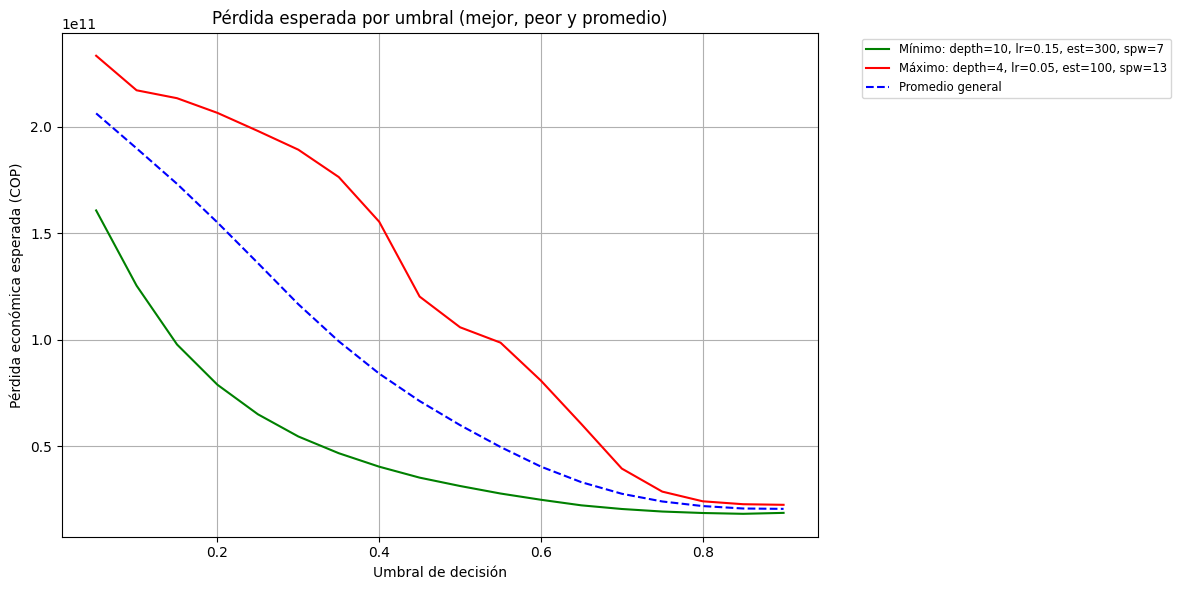

In [39]:
# Asegúrate de usar los mismos umbrales que usaste al entrenar
umbrales = np.arange(0.05, 0.95, 0.05)  # Esto da 18 puntos

# Paso 1: calcular la pérdida total por combinación
suma_por_modelo = {k: sum(v) for k, v in resultados.items()}

# Paso 2: identificar modelo con menor y mayor pérdida total
mejor_modelo = min(suma_por_modelo, key=suma_por_modelo.get)
peor_modelo = max(suma_por_modelo, key=suma_por_modelo.get)

# Paso 3: calcular promedio de pérdidas por umbral (punto a punto)
promedio_por_umbral = np.mean(np.array(list(resultados.values())), axis=0)

# Paso 4: graficar
plt.figure(figsize=(12, 6))

plt.plot(umbrales, resultados[mejor_modelo], 'g-', label=f"Mínimo: {mejor_modelo}")
plt.plot(umbrales, resultados[peor_modelo], 'r-', label=f"Máximo: {peor_modelo}")
plt.plot(umbrales, promedio_por_umbral, 'b--', label="Promedio general")

plt.title("Pérdida esperada por umbral (mejor, peor y promedio)")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [40]:
# Encontrar la combinación y umbral con menor pérdida
mejor_combinacion = None
mejor_umbral = None
mejor_perdida = float('inf')

for nombre, perdidas in resultados.items():
    idx_min = np.argmin(perdidas)
    if perdidas[idx_min] < mejor_perdida:
        mejor_perdida = perdidas[idx_min]
        mejor_combinacion = nombre
        mejor_umbral = umbrales[idx_min]

# Mostrar resultado óptimo
print("Mejor combinación encontrada:")
print(f"Parámetros: {mejor_combinacion}")
print(f"Umbral óptimo: {mejor_umbral:.2f}")
print(f"Pérdida mínima estimada: ${mejor_perdida:,.0f} COP")

Mejor combinación encontrada:
Parámetros: depth=10, lr=0.15, est=300, spw=11
Umbral óptimo: 0.90
Pérdida mínima estimada: $18,287,728,347 COP


In [41]:
# Crear y entrenar el modelo XGBoost
model_XGdef = XGBClassifier(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.15,
    scale_pos_weight=11,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=1
)

model_XGdef.fit(X_train, y_train)

# Obtener predicciones como probabilidades
y_proba_XGdef = model_XGdef.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
umbral = 0.90
y_pred_XG_customedef = (y_proba_XGdef >= umbral).astype(int)


# Evaluación del modelo
print(f"\n Evaluación del modelo XGBoost con umbral = {umbral}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_XG_customedef, target_names=['No Adición', 'Adición']))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_XG_customedef))

# Definir costos
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = salario_equipo_revision_alto   # Revisar innecesariamente un contrato

# Obtener métricas de la matriz de confusión
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_XG_customedef).ravel()

# Calcular pérdida económica total
perdida_total = (fn * costo_FN) + (fp * costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbral}: ${perdida_total:,.0f} COP")
print(fn,fp)

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:57:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Evaluación del modelo XGBoost con umbral = 0.9

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       0.93      0.98      0.96     28350
     Adición       0.78      0.43      0.56      3486

    accuracy                           0.92     31836
   macro avg       0.86      0.71      0.76     31836
weighted avg       0.92      0.92      0.91     31836

Matriz de confusión:
[[27916   434]
 [ 1978  1508]]

Costo total estimado con umbral = 0.9: $18,287,728,347 COP
1978 434


In [42]:
Costoporcontrato=perdida_total/len(X_test)
Costoporcontrato

574435.4927584002

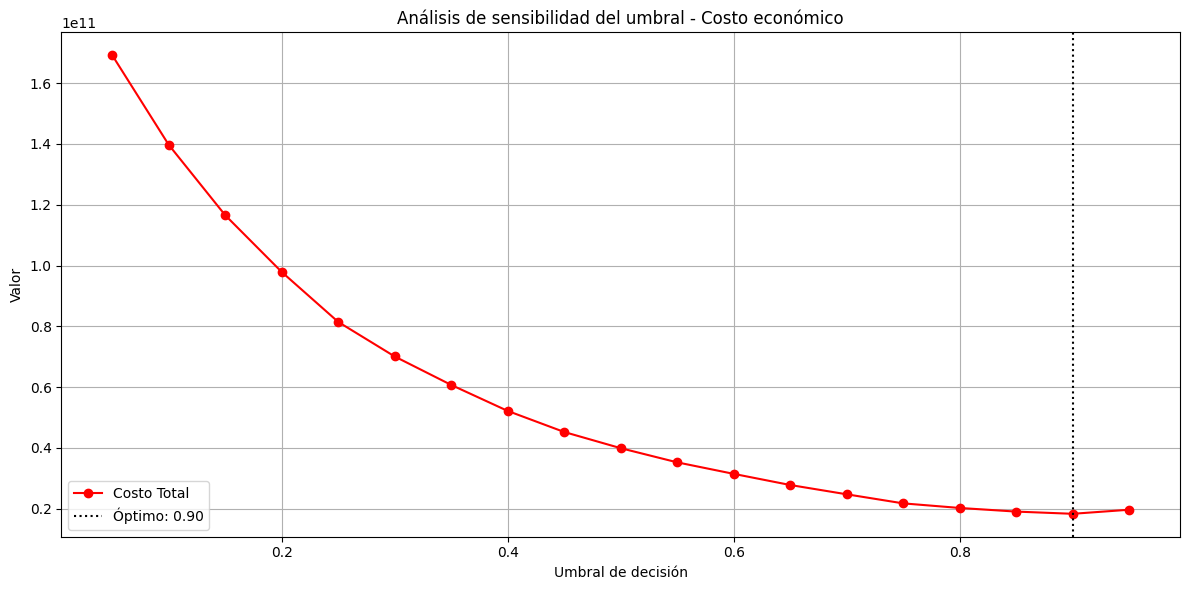

In [43]:
# Umbrales a probar
umbrales = np.arange(0.05, 0.96, 0.05)

# Resultados a guardar
falsos_positivos = []
falsos_negativos = []
costos = []

# Costos definidos
costo_FN = veinte_por_ciento
costo_FP = salario_equipo_revision_alto

# Calcular pérdida para cada umbral
for umbral_i in umbrales:
    y_pred_temp = (y_proba_XGdef >= umbral_i).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()

    costo_total = (fn * costo_FN) + (fp * costo_FP)
    falsos_positivos.append(fp)
    falsos_negativos.append(fn)
    costos.append(costo_total)

# Encontrar umbral óptimo
idx_optimo = np.argmin(costos)
umbral_optimo = umbrales[idx_optimo]
costo_minimo = costos[idx_optimo]

# Graficar resultados
plt.figure(figsize=(12, 6))
plt.plot(umbrales, costos, label='Costo Total', color='red', marker='o')

plt.axvline(x=umbral_optimo, linestyle=':', color='black', label=f'Óptimo: {umbral_optimo:.2f}')
plt.title("Análisis de sensibilidad del umbral - Costo económico")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
# Lista de umbrales con paso de 1%
umbrales = np.arange(0.05, 0.95, 0.01)

costos = []
fn_list = []
fp_list = []

# Evaluar costo por cada umbral
for umbral in umbrales:
    y_pred_umbral = (y_proba_XGdef >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_umbral).ravel()
    costo = (fn * costo_FN) + (fp * costo_FP)
    costos.append(costo)
    fn_list.append(fn)
    fp_list.append(fp)

# Calcular sensibilidad: cambio porcentual del costo entre umbrales
cambios = [0]  # no hay cambio para el primero
for i in range(1, len(costos)):
    cambio = (costos[i] - costos[i-1]) / costos[i-1] * 100
    cambios.append(cambio)

# Mostrar resumen tabular de los principales cambios
import pandas as pd

tabla_sensibilidad = pd.DataFrame({
    'Umbral': umbrales,
    'Costo Total': costos,
    'Cambio % vs anterior': cambios,
    'FN': fn_list,
    'FP': fp_list
})

# Mostrar top cambios fuertes
pd.set_option('display.float_format', '{:,.2f}'.format)
display(tabla_sensibilidad.head(10))  # o .tail(10) o todo

# Sensibilidad media (absoluta)
sensibilidad_alta = np.mean(np.abs(tabla_sensibilidad['Cambio % vs anterior'][1:]))  # sin el primero
print(f"Sensibilidad alta: {sensibilidad_alta:.2f}% por cada 1% de cambio en el umbral")


,Umbral,Costo Total,Cambio % vs anterior,FN,FP
0,0.05,"169,200,410,268.31",0.00,68,19659
1,0.06,"162,125,815,798.61",-4.18,78,18826
2,0.07,"156,190,096,847.74",-3.66,90,18124
3,0.08,"150,536,342,158.88",-3.62,103,17454
4,0.09,"145,163,333,145.85",-3.57,118,16815
5,0.10,"139,719,236,573.02",-3.75,135,16166
6,0.11,"134,525,267,436.00",-3.72,158,15541
7,0.12,"130,121,996,340.72",-3.27,180,15009
8,0.13,"125,390,147,537.57",-3.64,197,14443
9,0.14,"121,022,420,222.20",-3.48,218,13916


Sensibilidad alta: 2.52% por cada 1% de cambio en el umbral


## Random Forest

### Salario Bajo

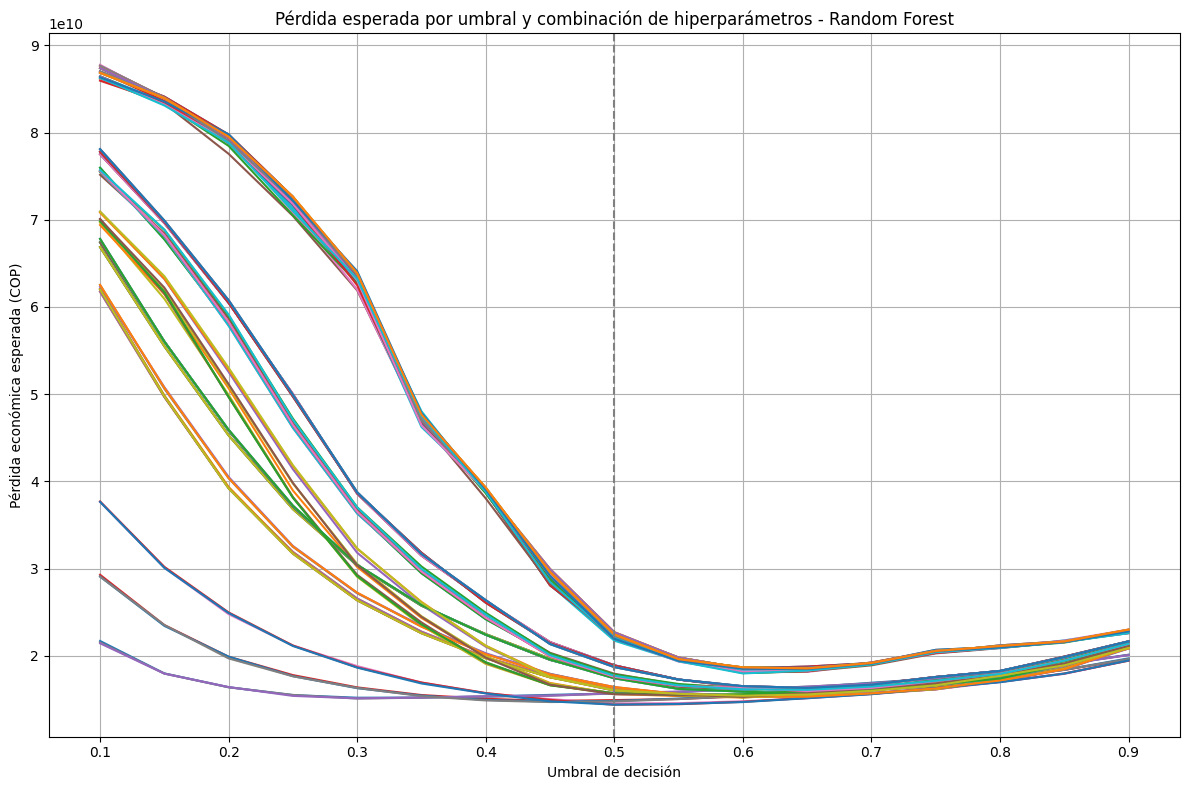

In [72]:
# Hiperparámetros a combinar
n_estimators_list = [100, 200,300]
max_depths = [None, 10, 20]
min_samples_splits = [2, 5,10]
min_samples_leafs = [1, 3,5]

# Costos
costo_FN = veinte_por_ciento  # Falso negativo (no detectar una adición)
costo_FP = salario_equipo_revision_bajo  # Falso positivo (revisar contrato innecesario)

# Umbrales
umbrales = np.arange(0.1, 0.95, 0.05)
resultados_rf = {}

# Todas las combinaciones posibles
combinaciones = list(product(n_estimators_list, max_depths, min_samples_splits, min_samples_leafs))

# Evaluación por combinación
for n_est, max_d, min_split, min_leaf in combinaciones:
    model = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=max_d,
        min_samples_split=min_split,
        min_samples_leaf=min_leaf,
        class_weight='balanced',
        random_state=42
    )
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    perdidas = []
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        perdida = (fn * costo_FN) + (fp * costo_FP)
        perdidas.append(perdida)

    etiqueta = f"n={n_est}, depth={max_d}, split={min_split}, leaf={min_leaf}"
    resultados_rf[etiqueta] = perdidas

# Graficar resultados
plt.figure(figsize=(12, 8))
for nombre, perdidas in resultados_rf.items():
    plt.plot(umbrales, perdidas, label=nombre)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada por umbral y combinación de hiperparámetros - Random Forest")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.grid(True)
plt.tight_layout()
plt.show()

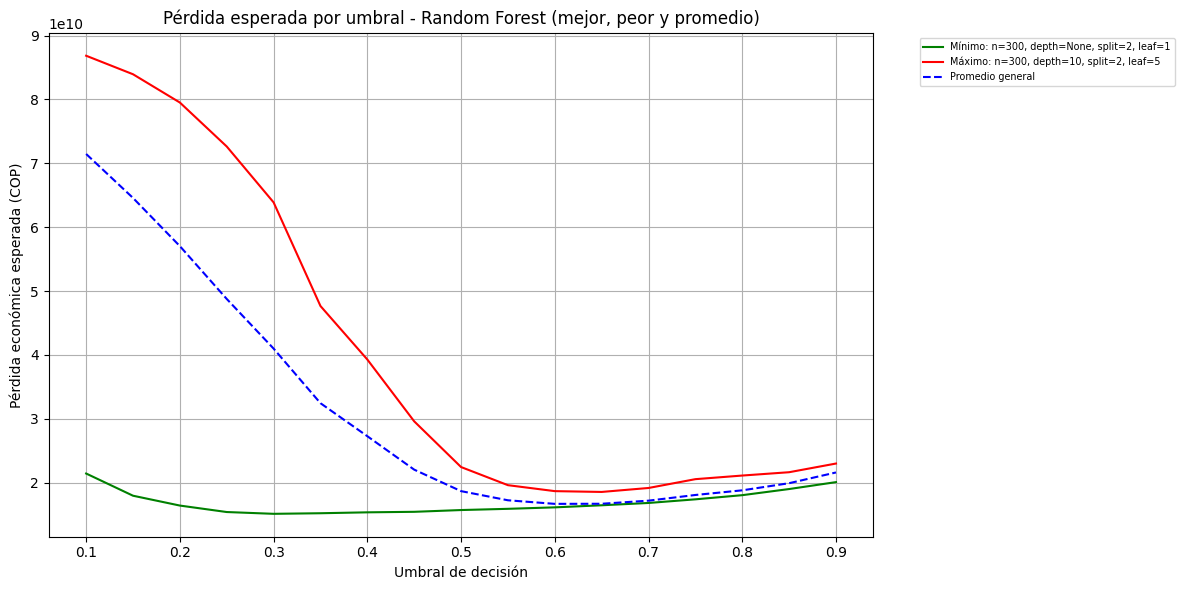

In [75]:
# Paso 1: calcular la pérdida total por combinación
suma_por_modelo = {k: sum(v) for k, v in resultados_rf.items()}

# Paso 2: identificar modelo con menor y mayor pérdida total
mejor_modelo = min(suma_por_modelo, key=suma_por_modelo.get)
peor_modelo = max(suma_por_modelo, key=suma_por_modelo.get)

# Paso 3: calcular promedio de pérdidas por umbral (punto a punto)
promedio_por_umbral = np.mean(np.array(list(resultados_rf.values())), axis=0)

# Paso 4: graficar
plt.figure(figsize=(12, 6))

plt.plot(umbrales, resultados_rf[mejor_modelo], 'g-', label=f"Mínimo: {mejor_modelo}")
plt.plot(umbrales, resultados_rf[peor_modelo], 'r-', label=f"Máximo: {peor_modelo}")
plt.plot(umbrales, promedio_por_umbral, 'b--', label="Promedio general")

plt.title("Pérdida esperada por umbral - Random Forest (mejor, peor y promedio)")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='x-small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()



In [84]:
# Encontrar la combinación y umbral con menor pérdida en RF
mejor_combinacion_rf = None
mejor_umbral_rf = None
mejor_perdida_rf = float('inf')

for nombre, perdidas in resultados_rf.items():
    idx_min = np.argmin(perdidas)
    if perdidas[idx_min] < mejor_perdida_rf:
        mejor_perdida_rf = perdidas[idx_min]
        mejor_combinacion_rf = nombre
        mejor_umbral_rf = umbrales[idx_min]

# Mostrar resultado óptimo
print("\nMejor combinación encontrada (Random Forest):")
print(f"Parámetros: {mejor_combinacion_rf}")
print(f"Umbral óptimo: {mejor_umbral_rf:.2f}")
print(f"Pérdida mínima estimada: ${mejor_perdida_rf:,.0f} COP")



Mejor combinación encontrada (Random Forest):
Parámetros: n=200, depth=None, split=10, leaf=1
Umbral óptimo: 0.13
Pérdida mínima estimada: $14,381,125,148 COP


In [83]:
# Inicializar valores
mejor_combinacion_rf = None
mejor_umbral_rf = None
mejor_perdida_rf = float('inf')

peor_combinacion_rf = None
peor_umbral_rf = None
peor_perdida_rf = float('-inf')

# Buscar mejor y peor combinación
for nombre, perdidas in resultados_rf.items():
    idx_min = np.argmin(perdidas)
    min_perdida = perdidas[idx_min]

    idx_max = np.argmax(perdidas)
    max_perdida = perdidas[idx_max]

    if min_perdida < mejor_perdida_rf:
        mejor_perdida_rf = min_perdida
        mejor_combinacion_rf = nombre
        mejor_umbral_rf = umbrales[idx_min]

    if max_perdida > peor_perdida_rf:
        peor_perdida_rf = max_perdida
        peor_combinacion_rf = nombre
        peor_umbral_rf = umbrales[idx_max]

# Calcular promedio por umbral (y mínimo del promedio)
promedio_por_umbral_rf = np.mean(np.array(list(resultados_rf.values())), axis=0)
idx_mejor_promedio_rf = np.argmin(promedio_por_umbral_rf)
mejor_umbral_promedio_rf = umbrales[idx_mejor_promedio_rf]
mejor_perdida_promedio_rf = promedio_por_umbral_rf[idx_mejor_promedio_rf]

# Mostrar resultados
print("\nMejor combinación (Random Forest):")
print(f"Parámetros: {mejor_combinacion_rf}")
print(f"Umbral óptimo: {mejor_umbral_rf:.2f}")
print(f"Pérdida mínima estimada: ${mejor_perdida_rf:,.0f} COP")

print("\nPeor combinación (Random Forest):")
print(f"Parámetros: {peor_combinacion_rf}")
print(f"Umbral más costoso: {peor_umbral_rf:.2f}")
print(f"Pérdida máxima estimada: ${peor_perdida_rf:,.0f} COP")

print("\nPromedio general (Random Forest):")
print(f"Umbral óptimo del promedio: {mejor_umbral_promedio_rf:.2f}")
print(f"Pérdida mínima promedio: ${mejor_perdida_promedio_rf:,.0f} COP")



Mejor combinación (Random Forest):
Parámetros: n=200, depth=None, split=10, leaf=1
Umbral óptimo: 0.13
Pérdida mínima estimada: $14,381,125,148 COP

Peor combinación (Random Forest):
Parámetros: n=100, depth=10, split=10, leaf=3
Umbral más costoso: 0.05
Pérdida máxima estimada: $87,771,922,350 COP

Promedio general (Random Forest):
Umbral óptimo del promedio: 0.15
Pérdida mínima promedio: $16,674,345,245 COP


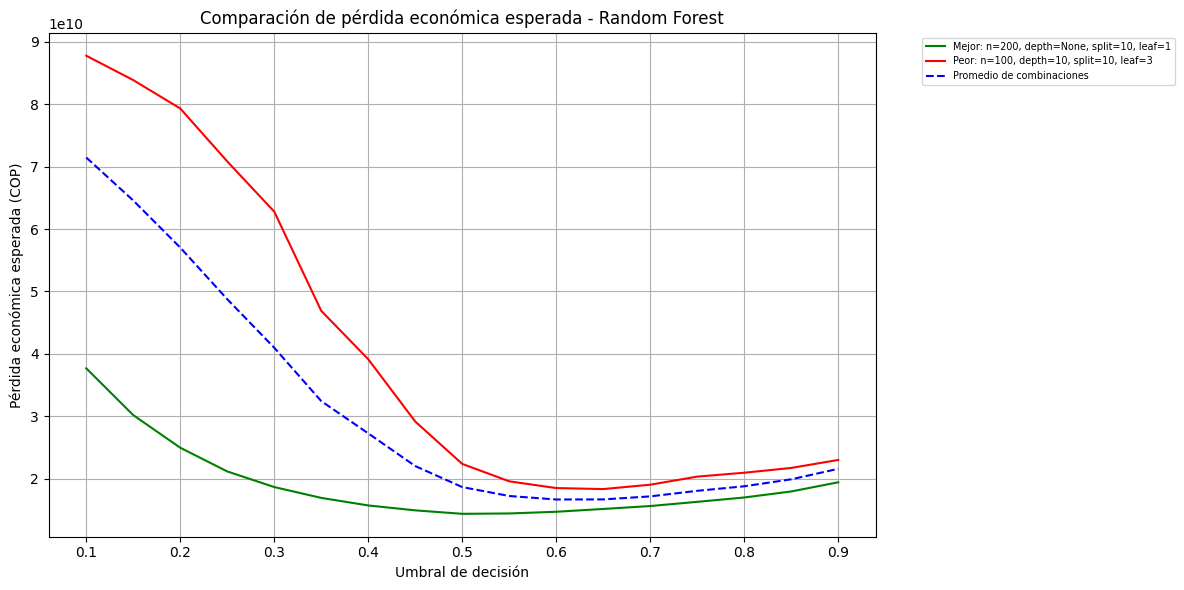

In [ ]:
# ⚠️ Asegúrate de usar el mismo rango de umbrales con el que creaste los modelos
umbrales = np.arange(0.1, 0.95, 0.05)

# Verificar longitudes antes de graficar
longitud_umbrales = len(umbrales)
longitud_mejor = len(resultados_rf[mejor_combinacion_rf])
longitud_peor = len(resultados_rf[peor_combinacion_rf])
longitud_promedio = len(promedio_por_umbral_rf)

if not (longitud_umbrales == longitud_mejor == longitud_peor == longitud_promedio):
    raise ValueError(f"Las longitudes no coinciden:\n"
                     f"umbrales = {longitud_umbrales}, "
                     f"mejor = {longitud_mejor}, "
                     f"peor = {longitud_peor}, "
                     f"promedio = {longitud_promedio}")

# Graficar resultados
plt.figure(figsize=(12, 6))

# Mejor modelo
plt.plot(umbrales, resultados_rf[mejor_combinacion_rf], 'g-', label=f"Mejor: {mejor_combinacion_rf}")


# Peor modelo
plt.plot(umbrales, resultados_rf[peor_combinacion_rf], 'r-', label=f"Peor: {peor_combinacion_rf}")


# Promedio
plt.plot(umbrales, promedio_por_umbral_rf, 'b--', label="Promedio de combinaciones")


# Estética del gráfico
plt.title("Comparación de pérdida económica esperada - Random Forest")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.grid(True)
plt.legend(fontsize='x-small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



In [78]:
# Crear y entrenar el modelo Random Forest
model_RF = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=1,
        class_weight='balanced',
        random_state=42)
# Entrenar el modelo
model_RF.fit(X_train, y_train)

# Hacer predicciones
y_pred_RF = model_RF.predict(X_test)

# Obtener probabilidades
y_proba_RF = model_RF.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
umbralrf = 0.5  # por ejemplo
y_pred_RF_custom = (y_proba_RF >= umbralrf).astype(int)

print(f"\nEvaluación con umbral = {umbralrf}\n")
print(classification_report(y_test, y_pred_RF_custom, target_names=['No Adición', 'Adición']))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_RF_custom))

# Definir costos
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = salario_equipo_revision_bajo    # Revisar innecesariamente un contrato

# Obtener métricas de la matriz de confusión
tnrf, fprf, fnrf, tprf = confusion_matrix(y_test, y_pred_RF_custom).ravel()

# Calcular pérdida económica total
perdida_totalrf = (fnrf * costo_FN) + (fprf* costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbralrf}: ${perdida_totalrf:,.0f} COP")
print(fnrf,fprf)


Evaluación con umbral = 0.5

              precision    recall  f1-score   support

  No Adición       0.95      0.94      0.95     28350
     Adición       0.58      0.63      0.61      3486

    accuracy                           0.91     31836
   macro avg       0.77      0.79      0.78     31836
weighted avg       0.91      0.91      0.91     31836

Matriz de confusión:
[[26788  1562]
 [ 1294  2192]]

Costo total estimado con umbral = 0.5: $14,381,125,148 COP
1294 1562


In [79]:
Costoporcontratorf=perdida_totalrf/len(X_test)
Costoporcontratorf

451725.2528015987

In [80]:
# Rango de umbrales
umbrales = np.arange(0.05, 0.95, 0.01)

costos_rf = []
cambios_rf = [0]
fn_list_rf = []
fp_list_rf = []

# Calcular costo por cada umbral
for umbral in umbrales:
    y_pred = (y_proba_RF >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    costo = (fn * costo_FN) + (fp * costo_FP)
    costos_rf.append(costo)
    fn_list_rf.append(fn)
    fp_list_rf.append(fp)

# Calcular cambio porcentual respecto al anterior
for i in range(1, len(costos_rf)):
    cambio = (costos_rf[i] - costos_rf[i-1]) / costos_rf[i-1] * 100
    cambios_rf.append(cambio)

# Tabla
tabla_sensibilidad_rf = pd.DataFrame({
    'Umbral': umbrales,
    'Costo Total': costos_rf,
    'Cambio % vs anterior': cambios_rf,
    'FN': fn_list_rf,
    'FP': fp_list_rf
})

# Mostrar primeras filas
pd.set_option('display.float_format', '{:,.2f}'.format)
display(tabla_sensibilidad_rf.head(10))

# Sensibilidad media (absoluta)
sensibilidad_bajo_rf = np.mean(np.abs(tabla_sensibilidad_rf['Cambio % vs anterior'][1:]))  # sin el primero
print(f"Sensibilidad bajo: {sensibilidad_bajo_rf:.2f}% por cada 1% de cambio en el umbral")



,Umbral,Costo Total,Cambio % vs anterior,FN,FP
0,0.05,"48,331,785,238.06",0.00,140,15222
1,0.06,"45,855,434,126.62",-5.12,170,14354
2,0.07,"43,721,234,452.99",-4.65,203,13589
3,0.08,"41,637,228,717.44",-4.77,231,12852
4,0.09,"39,633,679,397.90",-4.81,256,12148
5,0.10,"37,693,089,921.13",-4.90,279,11469
6,0.11,"35,992,918,958.35",-4.51,303,10865
7,0.12,"34,469,395,037.86",-4.23,332,10306
8,0.13,"33,045,644,521.37",-4.13,364,9772
9,0.14,"31,471,254,138.98",-4.76,392,9199


Sensibilidad bajo: 1.79% por cada 1% de cambio en el umbral


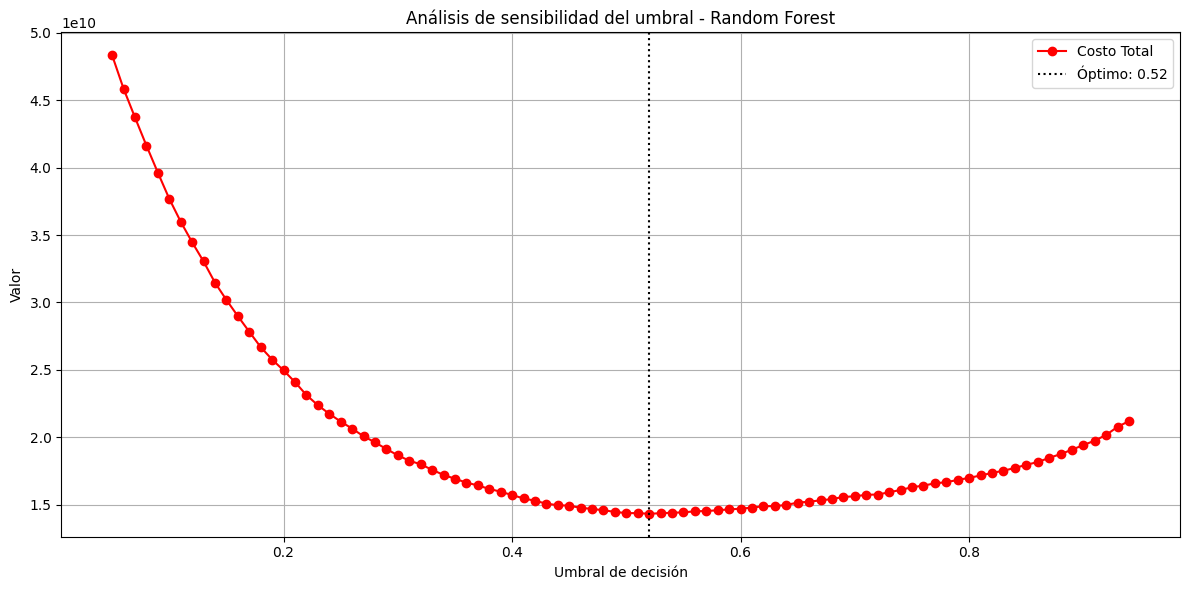

In [81]:
# Encontrar umbral de menor costo
idx_min_rf = np.argmin(costos_rf)
mejor_umbral_rf = umbrales[idx_min_rf]
mejor_costo_rf = costos_rf[idx_min_rf]

plt.figure(figsize=(12, 6))

# Línea de costo
plt.plot(umbrales, costos_rf, 'o-r', label='Costo Total')



# Línea vertical de umbral óptimo
plt.axvline(mejor_umbral_rf, color='black', linestyle=':', label=f'Óptimo: {mejor_umbral_rf:.2f}')

plt.title("Análisis de sensibilidad del umbral - Random Forest")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Salario medio

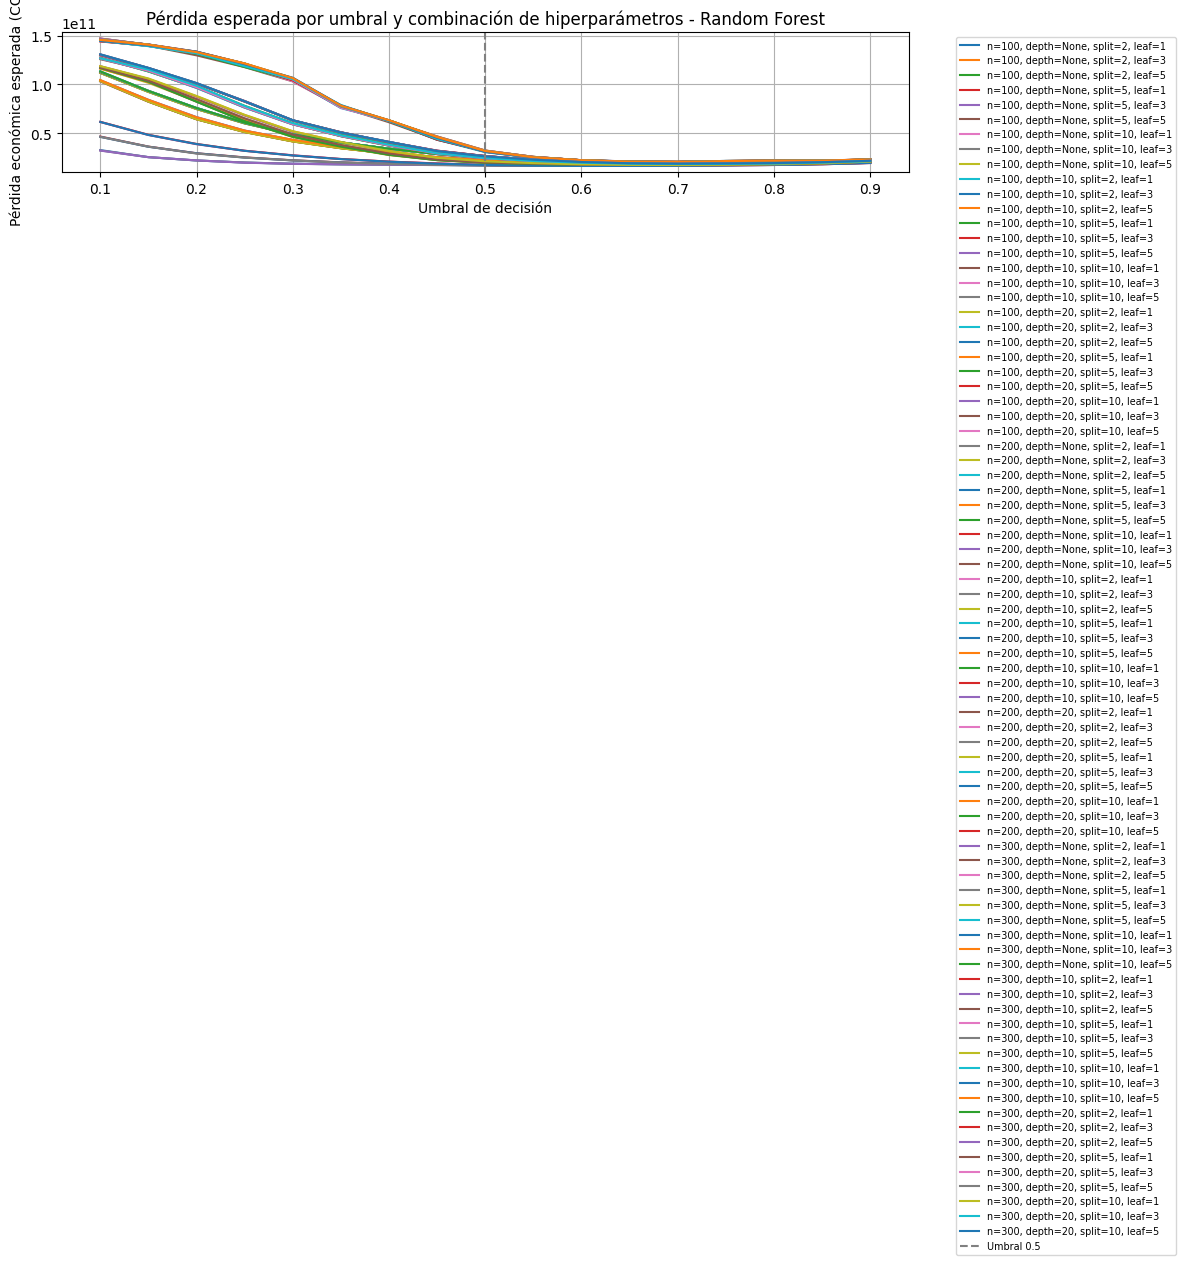

In [ ]:

# Hiperparámetros a combinar
n_estimators_list = [100, 200,300]
max_depths = [None, 10, 20]
min_samples_splits = [2, 5,10]
min_samples_leafs = [1, 3,5]

# Costos
costo_FN = veinte_por_ciento  # Falso negativo (no detectar una adición)
costo_FP = salario_equipo_revision_medio  # Falso positivo (revisar contrato innecesario)

# Umbrales
umbrales = np.arange(0.1, 0.95, 0.05)
resultados_rf = {}

# Todas las combinaciones posibles
combinaciones = list(product(n_estimators_list, max_depths, min_samples_splits, min_samples_leafs))

# Evaluación por combinación
for n_est, max_d, min_split, min_leaf in combinaciones:
    model = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=max_d,
        min_samples_split=min_split,
        min_samples_leaf=min_leaf,
        class_weight='balanced',
        random_state=42
    )
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    perdidas = []
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        perdida = (fn * costo_FN) + (fp * costo_FP)
        perdidas.append(perdida)

    etiqueta = f"n={n_est}, depth={max_d}, split={min_split}, leaf={min_leaf}"
    resultados_rf[etiqueta] = perdidas

# Graficar resultados
plt.figure(figsize=(12, 8))
for nombre, perdidas in resultados_rf.items():
    plt.plot(umbrales, perdidas, label=nombre)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada por umbral y combinación de hiperparámetros - Random Forest")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Paso 1: calcular la pérdida total por combinación
suma_por_modelo = {k: sum(v) for k, v in resultados_rf.items()}

# Paso 2: identificar modelo con menor y mayor pérdida total
mejor_modelo = min(suma_por_modelo, key=suma_por_modelo.get)
peor_modelo = max(suma_por_modelo, key=suma_por_modelo.get)

# Paso 3: calcular promedio de pérdidas por umbral (punto a punto)
promedio_por_umbral = np.mean(np.array(list(resultados_rf.values())), axis=0)

# Paso 4: graficar
plt.figure(figsize=(12, 6))

plt.plot(umbrales, resultados_rf[mejor_modelo], 'g-', label=f"Mínimo: {mejor_modelo}")
plt.plot(umbrales, resultados_rf[peor_modelo], 'r-', label=f"Máximo: {peor_modelo}")
plt.plot(umbrales, promedio_por_umbral, 'b--', label="Promedio general")

plt.title("Pérdida esperada por umbral - Random Forest (mejor, peor y promedio)")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='x-small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [51]:
# Encontrar la combinación y umbral con menor pérdida en RF
mejor_combinacion_rf = None
mejor_umbral_rf = None
mejor_perdida_rf = float('inf')

for nombre, perdidas in resultados_rf.items():
    idx_min = np.argmin(perdidas)
    if perdidas[idx_min] < mejor_perdida_rf:
        mejor_perdida_rf = perdidas[idx_min]
        mejor_combinacion_rf = nombre
        mejor_umbral_rf = umbrales[idx_min]

# Mostrar resultado óptimo
print("\nMejor combinación encontrada (Random Forest):")
print(f"Parámetros: {mejor_combinacion_rf}")
print(f"Umbral óptimo: {mejor_umbral_rf:.2f}")
print(f"Pérdida mínima estimada: ${mejor_perdida_rf:,.0f} COP")



Mejor combinación encontrada (Random Forest):
Parámetros: n=300, depth=None, split=10, leaf=1
Umbral óptimo: 0.60
Pérdida mínima estimada: $16,645,262,856 COP


In [ ]:
# Crear y entrenar el modelo Random Forest
model_RF = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=1,
        class_weight='balanced',
        random_state=42)
# Entrenar el modelo
model_RF.fit(X_train, y_train)

# Hacer predicciones
y_pred_RF = model_RF.predict(X_test)

# Obtener probabilidades
y_proba_RF = model_RF.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
umbralrf = 0.6  # por ejemplo
y_pred_RF_custom = (y_proba_RF >= umbralrf).astype(int)

print(f"\nEvaluación con umbral = {umbralrf}\n")
print(classification_report(y_test, y_pred_RF_custom, target_names=['No Adición', 'Adición']))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_RF_custom))

# Definir costos
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = salario_equipo_revision_medio    # Revisar innecesariamente un contrato

# Obtener métricas de la matriz de confusión
tnrf, fprf, fnrf, tprf = confusion_matrix(y_test, y_pred_RF_custom).ravel()

# Calcular pérdida económica total
perdida_totalrf = (fnrf * costo_FN) + (fprf* costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbralrf}: ${perdida_totalrf:,.0f} COP")
print(fnrf,fprf)



Evaluación con umbral = 0.6

              precision    recall  f1-score   support

  No Adición       0.94      0.97      0.96     28350
     Adición       0.67      0.54      0.60      3486

    accuracy                           0.92     31836
   macro avg       0.81      0.75      0.78     31836
weighted avg       0.91      0.92      0.92     31836

Matriz de confusión:
[[27417   933]
 [ 1601  1885]]

Costo total estimado con umbral = 0.6: $16,645,262,856 COP
1601 933


In [72]:
Costoporcontratorf=perdida_totalrf/len(X_test)
Costoporcontratorf

522844.0399561345

In [73]:
# Rango de umbrales
umbrales = np.arange(0.05, 0.95, 0.01)

costos_rf = []
cambios_rf = [0]
fn_list_rf = []
fp_list_rf = []

# Calcular costo por cada umbral
for umbral in umbrales:
    y_pred = (y_proba_RF >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    costo = (fn * costo_FN) + (fp * costo_FP)
    costos_rf.append(costo)
    fn_list_rf.append(fn)
    fp_list_rf.append(fp)

# Calcular cambio porcentual respecto al anterior
for i in range(1, len(costos_rf)):
    cambio = (costos_rf[i] - costos_rf[i-1]) / costos_rf[i-1] * 100
    cambios_rf.append(cambio)

# Tabla
tabla_sensibilidad_rf = pd.DataFrame({
    'Umbral': umbrales,
    'Costo Total': costos_rf,
    'Cambio % vs anterior': cambios_rf,
    'FN': fn_list_rf,
    'FP': fp_list_rf
})

# Mostrar primeras filas
pd.set_option('display.float_format', '{:,.2f}'.format)
display(tabla_sensibilidad_rf.head(10))

# Sensibilidad media (absoluta)
sensibilidad_media_rf = np.mean(np.abs(tabla_sensibilidad_rf['Cambio % vs anterior'][1:]))  # sin el primero
print(f"Sensibilidad media: {sensibilidad_media_rf:.2f}% por cada 1% de cambio en el umbral")



,Umbral,Costo Total,Cambio % vs anterior,FN,FP
0,0.05,"80,355,316,119.76",0.00,140,15236
1,0.06,"76,132,097,963.59",-5.26,171,14381
2,0.07,"72,152,317,488.24",-5.23,199,13577
3,0.08,"68,569,116,286.22",-4.97,225,12852
4,0.09,"65,078,736,337.40",-5.09,253,12142
5,0.10,"61,676,864,994.43",-5.23,281,11449
6,0.11,"58,709,805,127.34",-4.81,303,10848
7,0.12,"56,096,779,683.68",-4.45,325,10315
8,0.13,"53,302,793,222.15",-4.98,350,9743
9,0.14,"50,793,739,491.22",-4.71,384,9213


Sensibilidad media: 2.05% por cada 1% de cambio en el umbral


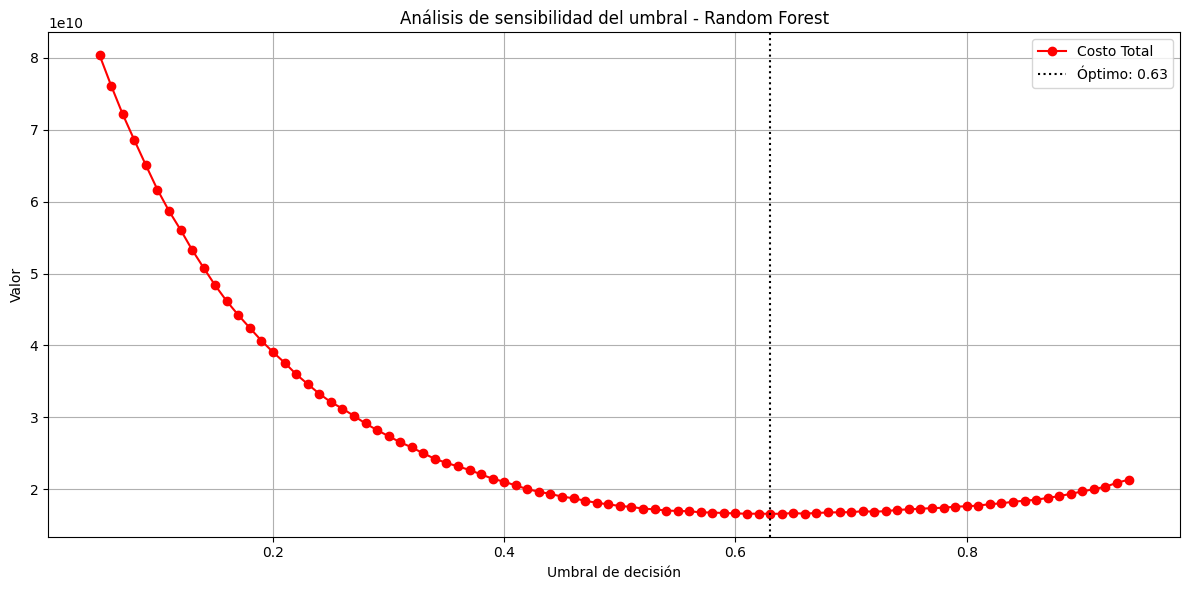

In [74]:
# Encontrar umbral de menor costo
idx_min_rf = np.argmin(costos_rf)
mejor_umbral_rf = umbrales[idx_min_rf]
mejor_costo_rf = costos_rf[idx_min_rf]

plt.figure(figsize=(12, 6))

# Línea de costo
plt.plot(umbrales, costos_rf, 'o-r', label='Costo Total')



# Línea vertical de umbral óptimo
plt.axvline(mejor_umbral_rf, color='black', linestyle=':', label=f'Óptimo: {mejor_umbral_rf:.2f}')

plt.title("Análisis de sensibilidad del umbral - Random Forest")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Salario Alto

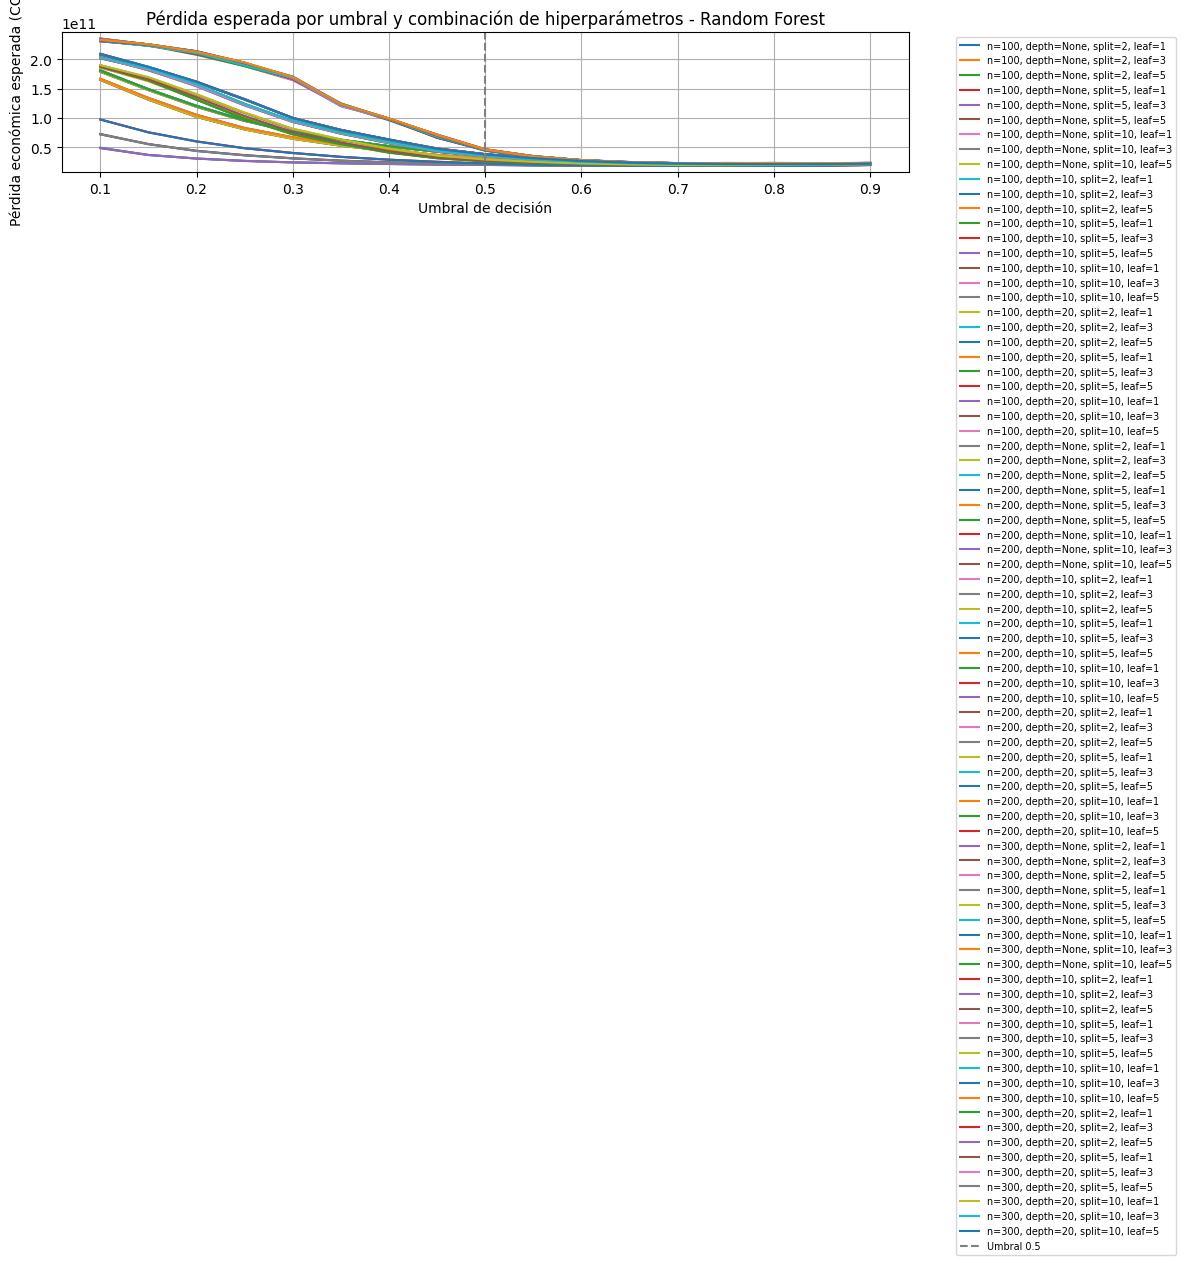

In [ ]:
# Hiperparámetros a combinar
n_estimators_list = [100, 200,300]
max_depths = [None, 10, 20]
min_samples_splits = [2, 5,10]
min_samples_leafs = [1, 3,5]

# Costos
costo_FN = veinte_por_ciento  # Falso negativo (no detectar una adición)
costo_FP = salario_equipo_revision_alto  # Falso positivo (revisar contrato innecesario)

# Umbrales
umbrales = np.arange(0.1, 0.95, 0.05)
resultados_rf = {}

# Todas las combinaciones posibles
combinaciones = list(product(n_estimators_list, max_depths, min_samples_splits, min_samples_leafs))

# Evaluación por combinación
for n_est, max_d, min_split, min_leaf in combinaciones:
    model = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=max_d,
        min_samples_split=min_split,
        min_samples_leaf=min_leaf,
        class_weight='balanced',
        random_state=42
    )
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    perdidas = []
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        perdida = (fn * costo_FN) + (fp * costo_FP)
        perdidas.append(perdida)

    etiqueta = f"n={n_est}, depth={max_d}, split={min_split}, leaf={min_leaf}"
    resultados_rf[etiqueta] = perdidas

# Graficar resultados
plt.figure(figsize=(12, 8))
for nombre, perdidas in resultados_rf.items():
    plt.plot(umbrales, perdidas, label=nombre)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada por umbral y combinación de hiperparámetros - Random Forest")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='x-small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Paso 1: calcular la pérdida total por combinación
suma_por_modelo = {k: sum(v) for k, v in resultados_rf.items()}

# Paso 2: identificar modelo con menor y mayor pérdida total
mejor_modelo = min(suma_por_modelo, key=suma_por_modelo.get)
peor_modelo = max(suma_por_modelo, key=suma_por_modelo.get)

# Paso 3: calcular promedio de pérdidas por umbral (punto a punto)
promedio_por_umbral = np.mean(np.array(list(resultados_rf.values())), axis=0)

# Paso 4: graficar
plt.figure(figsize=(12, 6))

plt.plot(umbrales, resultados_rf[mejor_modelo], 'g-', label=f"Mínimo: {mejor_modelo}")
plt.plot(umbrales, resultados_rf[peor_modelo], 'r-', label=f"Máximo: {peor_modelo}")
plt.plot(umbrales, promedio_por_umbral, 'b--', label="Promedio general")

plt.title("Pérdida esperada por umbral - Random Forest (mejor, peor y promedio)")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='x-small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [75]:
# Encontrar la combinación y umbral con menor pérdida en RF
mejor_combinacion_rf = None
mejor_umbral_rf = None
mejor_perdida_rf = float('inf')

for nombre, perdidas in resultados_rf.items():
    idx_min = np.argmin(perdidas)
    if perdidas[idx_min] < mejor_perdida_rf:
        mejor_perdida_rf = perdidas[idx_min]
        mejor_combinacion_rf = nombre
        mejor_umbral_rf = umbrales[idx_min]

# Mostrar resultado óptimo
print("\nMejor combinación encontrada (Random Forest):")
print(f"Parámetros: {mejor_combinacion_rf}")
print(f"Umbral óptimo: {mejor_umbral_rf:.2f}")
print(f"Pérdida mínima estimada: ${mejor_perdida_rf:,.0f} COP")


Mejor combinación encontrada (Random Forest):
Parámetros: n=100, depth=None, split=5, leaf=1
Umbral óptimo: 0.17
Pérdida mínima estimada: $18,437,370,589 COP


In [ ]:
# Crear y entrenar el modelo Random Forest
model_RF = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=1,
        class_weight='balanced',
        random_state=42)
# Entrenar el modelo
model_RF.fit(X_train, y_train)

# Hacer predicciones
y_pred_RF = model_RF.predict(X_test)

# Obtener probabilidades
y_proba_RF = model_RF.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
umbralrf = 0.7  # por ejemplo
y_pred_RF_custom = (y_proba_RF >= umbralrf).astype(int)

print(f"\nEvaluación con umbral = {umbralrf}\n")
print(classification_report(y_test, y_pred_RF_custom, target_names=['No Adición', 'Adición']))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_RF_custom))

# Definir costos
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = salario_equipo_revision_alto    # Revisar innecesariamente un contrato

# Obtener métricas de la matriz de confusión
tnrf, fprf, fnrf, tprf = confusion_matrix(y_test, y_pred_RF_custom).ravel()

# Calcular pérdida económica total
perdida_totalrf = (fnrf * costo_FN) + (fprf* costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbralrf}: ${perdida_totalrf:,.0f} COP")
print(fnrf,fprf)


Evaluación con umbral = 0.7

              precision    recall  f1-score   support

  No Adición       0.93      0.98      0.96     28350
     Adición       0.77      0.42      0.55      3486

    accuracy                           0.92     31836
   macro avg       0.85      0.70      0.75     31836
weighted avg       0.92      0.92      0.91     31836

Matriz de confusión:
[[27921   429]
 [ 2018  1468]]

Costo total estimado con umbral = 0.7: $18,437,370,589 COP
2018 429


In [77]:
Costoporcontratorf=perdida_totalrf/len(X_test)
Costoporcontratorf

579135.9023998865

In [ ]:
# Rango de umbrales
umbrales = np.arange(0.05, 0.95, 0.01)

costos_rf = []
cambios_rf = [0]
fn_list_rf = []
fp_list_rf = []

# Calcular costo por cada umbral
for umbral in umbrales:
    y_pred = (y_proba_RF >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    costo = (fn * costo_FN) + (fp * costo_FP)
    costos_rf.append(costo)
    fn_list_rf.append(fn)
    fp_list_rf.append(fp)

# Calcular cambio porcentual respecto al anterior
for i in range(1, len(costos_rf)):
    cambio = (costos_rf[i] - costos_rf[i-1]) / costos_rf[i-1] * 100
    cambios_rf.append(cambio)

# Tabla
tabla_sensibilidad_rf = pd.DataFrame({
    'Umbral': umbrales,
    'Costo Total': costos_rf,
    'Cambio % vs anterior': cambios_rf,
    'FN': fn_list_rf,
    'FP': fp_list_rf
})

# Mostrar primeras filas
pd.set_option('display.float_format', '{:,.2f}'.format)
display(tabla_sensibilidad_rf.head(10))


# Sensibilidad media (absoluta)
sensibilidad_alto_rf = np.mean(np.abs(tabla_sensibilidad_rf['Cambio % vs anterior'][1:]))  # sin el primero
print(f"Sensibilidad alto: {sensibilidad_alto_rf:.2f}% por cada 1% de cambio en el umbral")


,Umbral,Costo Total,Cambio % vs anterior,FN,FP
0,0.05,"99,998,603,740.01",0.00,289,11730
1,0.06,"93,039,555,006.72",-6.96,332,10858
2,0.07,"86,919,773,862.19",-6.58,370,10091
3,0.08,"81,788,464,728.66",-5.90,404,9446
4,0.09,"76,936,915,344.13",-5.93,442,8831
5,0.10,"72,913,335,506.86",-5.23,461,8332
6,0.11,"68,893,690,998.84",-5.51,493,7822
7,0.12,"65,114,534,555.06",-5.49,518,7347
8,0.13,"61,890,477,650.29",-4.95,547,6935
9,0.14,"58,768,506,141.02",-5.04,574,6537


Sensibilidad media: 2.04% por cada 1% de cambio en el umbral


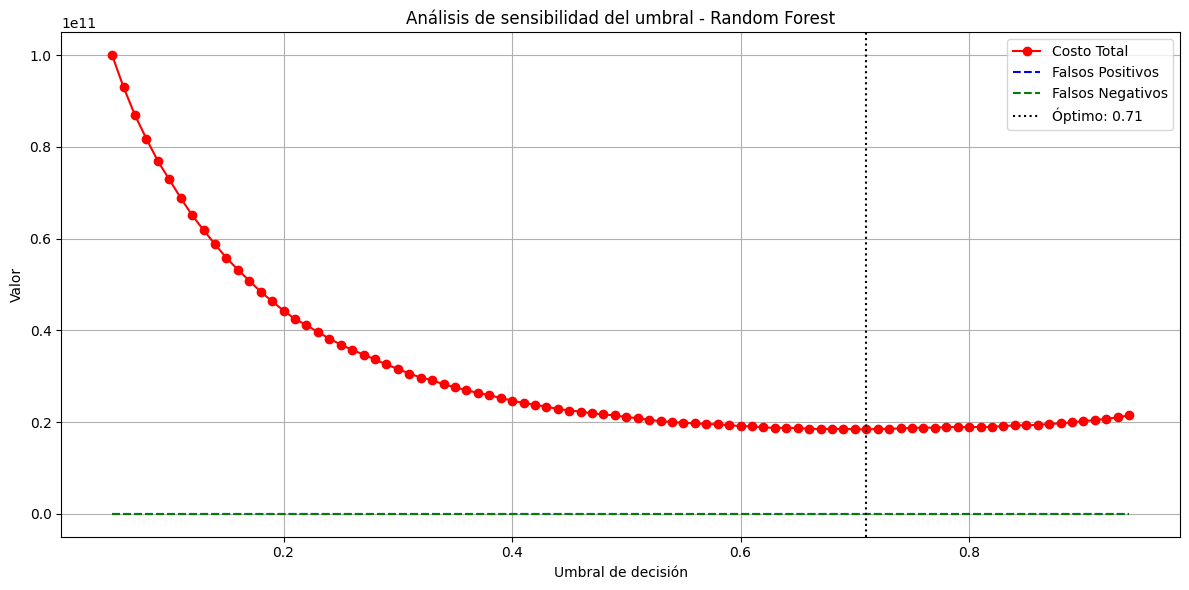

In [79]:
# Encontrar umbral de menor costo
idx_min_rf = np.argmin(costos_rf)
mejor_umbral_rf = umbrales[idx_min_rf]
mejor_costo_rf = costos_rf[idx_min_rf]

plt.figure(figsize=(12, 6))

# Línea de costo
plt.plot(umbrales, costos_rf, 'o-r', label='Costo Total')

# Líneas de FP y FN (opcional)
plt.plot(umbrales, fp_list_rf, '--b', label='Falsos Positivos')
plt.plot(umbrales, fn_list_rf, '--g', label='Falsos Negativos')

# Línea vertical de umbral óptimo
plt.axvline(mejor_umbral_rf, color='black', linestyle=':', label=f'Óptimo: {mejor_umbral_rf:.2f}')

plt.title("Análisis de sensibilidad del umbral - Random Forest")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Modelo LGB

### Salario Bajo

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 14468, number of negative: 112877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011519 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1888
[LightGBM] [Info] Number of data points in the train set: 127345, number of used features: 307
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

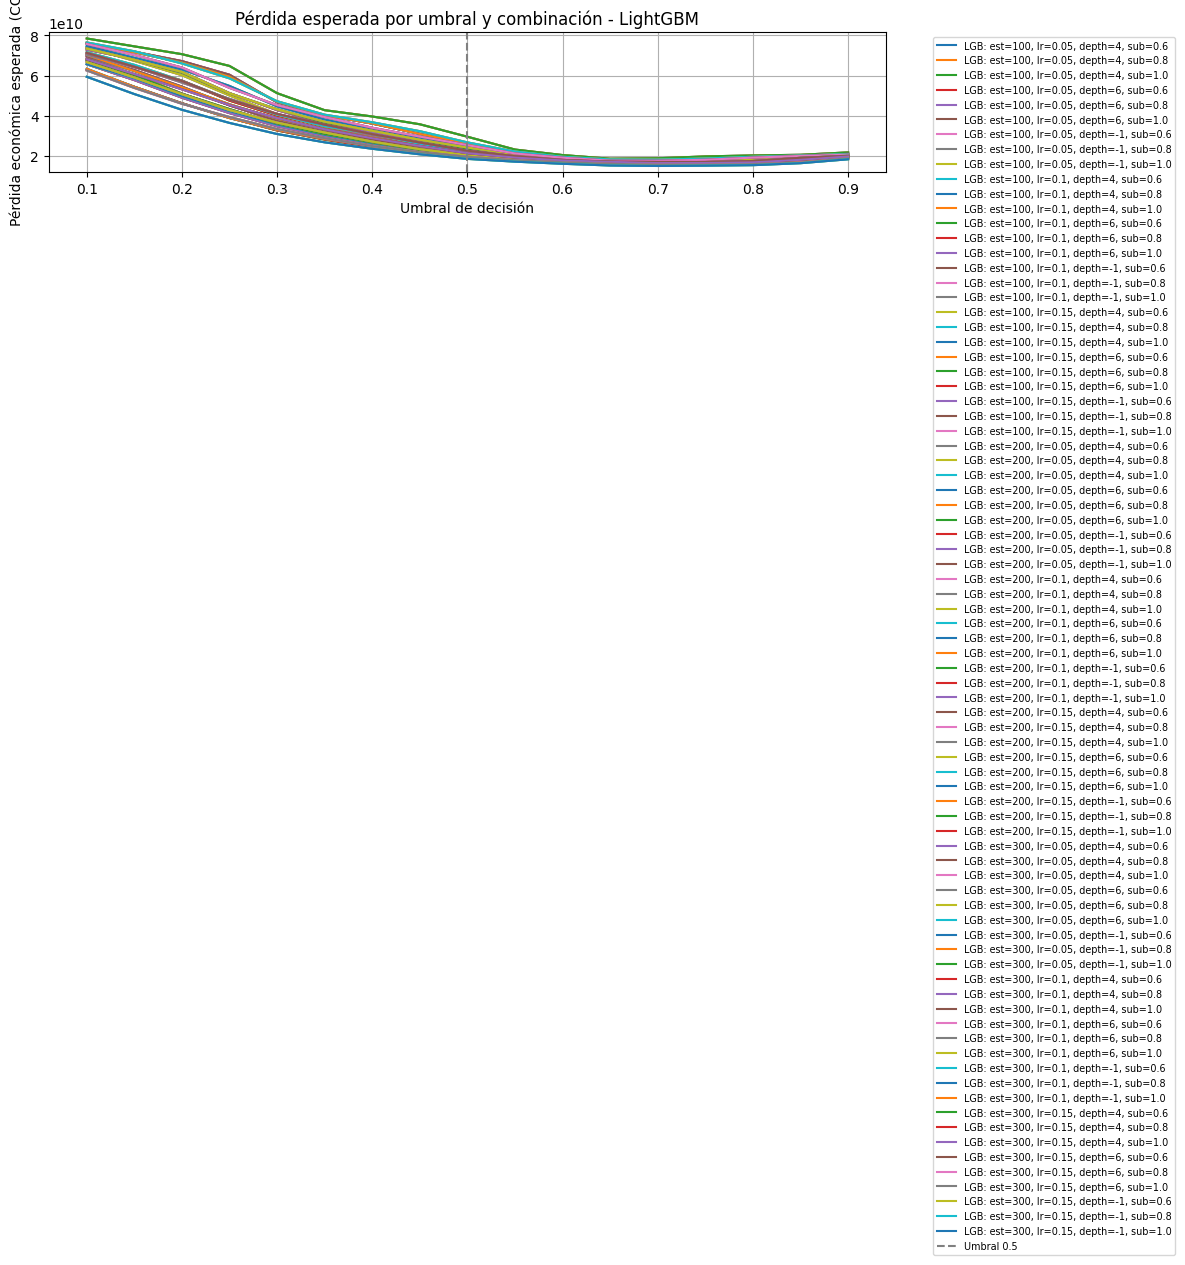

In [ ]:
# Hiperparámetros a probar
n_estimators_list = [100, 200,300]
learning_rates = [0.05, 0.1,0.15]
max_depths = [4, 6, -1]
subsamples = [0.6, 0.8, 1.0]

# Costos
costo_FN = veinte_por_ciento
costo_FP = salario_equipo_revision_bajo

# Umbrales
umbrales = np.arange(0.1, 0.95, 0.05)
resultados_lgb = {}

# Todas las combinaciones posibles
combinaciones = list(product(n_estimators_list, learning_rates, max_depths, subsamples))

# Evaluar cada combinación
for n_est, lr, max_d, subsample in combinaciones:
    model = lgb.LGBMClassifier(
        n_estimators=n_est,
        learning_rate=lr,
        max_depth=max_d,
        subsample=subsample,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=42
    )
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    perdidas = []
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        perdida = (fn * costo_FN) + (fp * costo_FP)
        perdidas.append(perdida)

    etiqueta = f"LGB: est={n_est}, lr={lr}, depth={max_d}, sub={subsample}"
    resultados_lgb[etiqueta] = perdidas

# Graficar
plt.figure(figsize=(12, 8))
for nombre, perdidas in resultados_lgb.items():
    plt.plot(umbrales, perdidas, label=nombre)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada por umbral y combinación - LightGBM")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.grid(True)
plt.tight_layout()
plt.show()

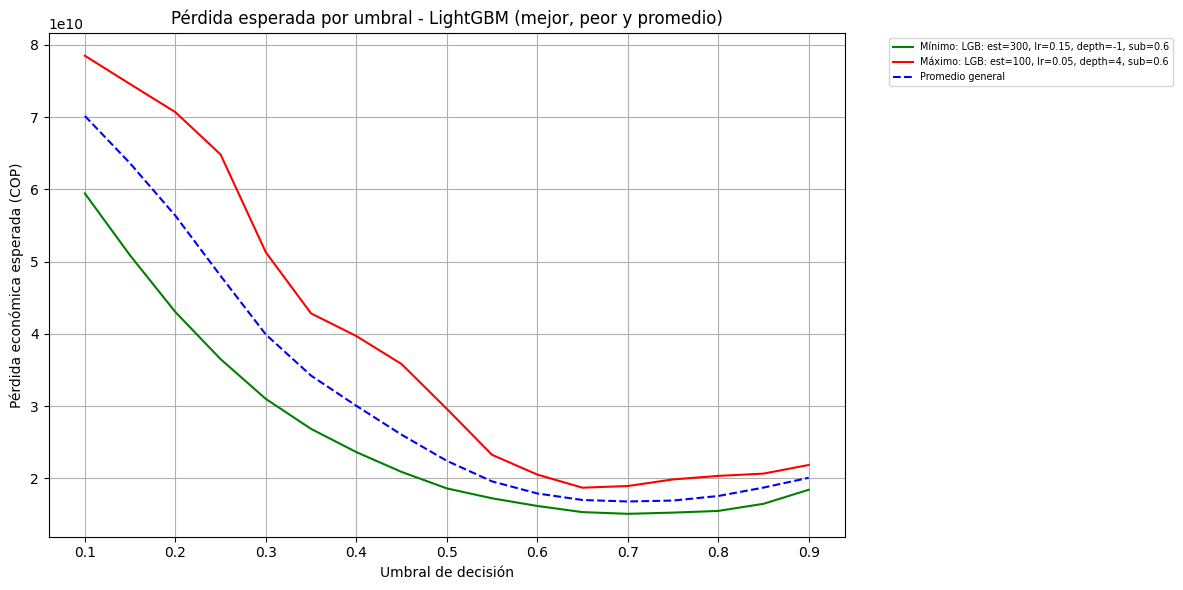

In [ ]:
# Paso 1: Calcular la pérdida total por modelo (sumatoria de cada lista de pérdidas)
suma_por_modelo_lgb = {k: sum(v) for k, v in resultados_lgb.items()}

# Paso 2: Identificar mejor y peor combinación
mejor_modelo_lgb = min(suma_por_modelo_lgb, key=suma_por_modelo_lgb.get)
peor_modelo_lgb = max(suma_por_modelo_lgb, key=suma_por_modelo_lgb.get)

# Paso 3: Calcular promedio de pérdidas por umbral (promedio fila por fila)
promedio_por_umbral_lgb = np.mean(np.array(list(resultados_lgb.values())), axis=0)

# Paso 4: Gráfica final
plt.figure(figsize=(12, 6))

plt.plot(umbrales, resultados_lgb[mejor_modelo_lgb], 'g-', label=f"Mínimo: {mejor_modelo_lgb}")
plt.plot(umbrales, resultados_lgb[peor_modelo_lgb], 'r-', label=f"Máximo: {peor_modelo_lgb}")
plt.plot(umbrales, promedio_por_umbral_lgb, 'b--', label="Promedio general")

plt.title("Pérdida esperada por umbral - LightGBM (mejor, peor y promedio)")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='x-small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Encontrar la combinación y umbral con menor pérdida en LightGBM
mejor_combinacion_lgb = None
mejor_umbral_lgb = None
mejor_perdida_lgb = float('inf')

for nombre, perdidas in resultados_lgb.items():
    idx_min = np.argmin(perdidas)
    if perdidas[idx_min] < mejor_perdida_lgb:
        mejor_perdida_lgb = perdidas[idx_min]
        mejor_combinacion_lgb = nombre
        mejor_umbral_lgb = umbrales[idx_min]

# Mostrar resultado óptimo
print("\nMejor combinación encontrada (LightGBM):")
print(f"Parámetros: {mejor_combinacion_lgb}")
print(f"Umbral óptimo: {mejor_umbral_lgb:.2f}")
print(f"Pérdida mínima estimada: ${mejor_perdida_lgb:,.0f} COP")


Mejor combinación encontrada (LightGBM):
Parámetros: LGB: est=300, lr=0.15, depth=-1, sub=0.6
Umbral óptimo: 0.70
Pérdida mínima estimada: $15,092,142,774 COP


In [ ]:
# Crear y entrenar el modelo LightGBM
model_LGB = lgb.LGBMClassifier(
    n_estimators=300,          # Número de árboles
    max_depth=-1,              # Sin límite de profundidad
    learning_rate=0.15,        # Tasa de aprendizaje
    subsample=0.6,             # Proporción de datos para cada árbol
    colsample_bytree=0.8,      # Proporción de características para cada árbol
    class_weight='balanced',   # Manejo de clases desbalanceadas
    random_state=42            # Para reproducibilidad
)

# Entrenar el modelo
model_LGB.fit(X_train, y_train)

# Definir el umbral deseado
umbral_lgb = 0.7  # Puedes cambiarlo según lo que quieras probar

# Predecir probabilidades
y_proba_LGB = model_LGB.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
y_pred_LGB_custom = (y_proba_LGB >= umbral_lgb).astype(int)

# Evaluación
print(f"\nEvaluación del modelo LightGBM con umbral = {umbral_lgb}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_LGB_custom, target_names=['No Adición', 'Adición']))

# Matriz de confusión
conf_matrix_LGB = confusion_matrix(y_test, y_pred_LGB_custom)
print("\nMatriz de confusión:")
print(conf_matrix_LGB)

# Definir costos
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = salario_equipo_revision_bajo               # Revisar innecesariamente un contrato

# Obtener métricas de la matriz de confusión
tnlgb, fplgb, fnlgb, tplgb = conf_matrix_LGB.ravel()

# Calcular pérdida económica total
perdida_total_lgb = (fnlgb * costo_FN) + (fplgb * costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbral_lgb}: ${perdida_total_lgb:,.0f} COP")
print(f"FN = {fnlgb}, FP = {fplgb}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 14468, number of negative: 112877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009001 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1888
[LightGBM] [Info] Number of data points in the train set: 127345, number of used features: 307
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

Evaluación del modelo LightGBM con umbral = 0.7

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       0.95      0.94      0.95     28350
     Adición       0.57      0.61      0.59      3486

    accuracy                           0.91     31836
   macro avg       0.76      0.77      0.77     31836
weighted avg 

In [ ]:
Costoporcontratolgb=perdida_total_lgb/len(X_test)
Costoporcontratolgb

474059.01413450483

In [ ]:
# Rango de umbrales
umbrales = np.arange(0.05, 0.95, 0.01)

costos_lgb = []
cambios_lgb = [0]
fn_list_lgb = []
fp_list_lgb = []

# Evaluar cada umbral
for umbral in umbrales:
    y_pred = (y_proba_LGB >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    costo = (fn * costo_FN) + (fp * costo_FP)
    costos_lgb.append(costo)
    fn_list_lgb.append(fn)
    fp_list_lgb.append(fp)

# Cambios porcentuales entre umbrales
for i in range(1, len(costos_lgb)):
    cambio = (costos_lgb[i] - costos_lgb[i-1]) / costos_lgb[i-1] * 100
    cambios_lgb.append(cambio)

# Tabla resumen
tabla_sensibilidad_lgb = pd.DataFrame({
    'Umbral': umbrales,
    'Costo Total': costos_lgb,
    'Cambio % vs anterior': cambios_lgb,
    'FN': fn_list_lgb,
    'FP': fp_list_lgb
})

pd.set_option('display.float_format', '{:,.2f}'.format)
display(tabla_sensibilidad_lgb.head(10))  # Puedes cambiar a .tail() o mostrar todo

# Sensibilidad media (absoluta)
sensibilidad_bajo_lgb = np.mean(np.abs(tabla_sensibilidad_lgb['Cambio % vs anterior'][1:]))  # sin el primero
print(f"Sensibilidad bajo: {sensibilidad_bajo_lgb:.2f}% por cada 1% de cambio en el umbral")


,Umbral,Costo Total,Cambio % vs anterior,FN,FP
0,0.05,"67,906,501,017.05",0.00,30,21782
1,0.06,"66,207,419,893.46",-2.50,36,21221
2,0.07,"64,622,165,074.53",-2.39,41,20699
3,0.08,"62,987,527,946.47",-2.53,49,20154
4,0.09,"61,073,223,856.31",-3.04,57,19519
5,0.10,"59,447,433,593.29",-2.66,70,18965
6,0.11,"57,602,640,429.18",-3.10,79,18350
7,0.12,"56,018,058,134.08",-2.75,90,17814
8,0.13,"54,212,849,680.00",-3.22,101,17207
9,0.14,"52,536,192,955.06",-3.09,113,16639


Sensibilidad bajo: 2.02% por cada 1% de cambio en el umbral


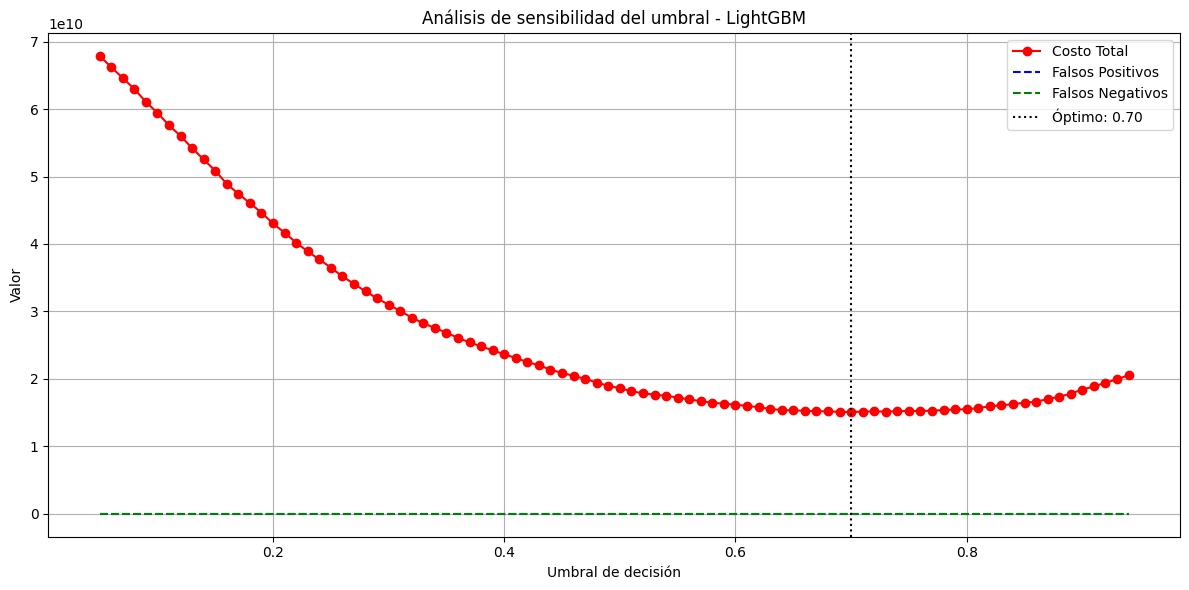

In [ ]:
# Encontrar umbral de menor costo
idx_min_lgb = np.argmin(costos_lgb)
mejor_umbral_lgb = umbrales[idx_min_lgb]
mejor_costo_lgb = costos_lgb[idx_min_lgb]

plt.figure(figsize=(12, 6))

# Línea de costo
plt.plot(umbrales, costos_lgb, 'o-r', label='Costo Total')

# FP y FN (opcional)
plt.plot(umbrales, fp_list_lgb, '--b', label='Falsos Positivos')
plt.plot(umbrales, fn_list_lgb, '--g', label='Falsos Negativos')

# Umbral óptimo
plt.axvline(mejor_umbral_lgb, color='black', linestyle=':', label=f'Óptimo: {mejor_umbral_lgb:.2f}')

plt.title("Análisis de sensibilidad del umbral - LightGBM")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Salario medio

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 14468, number of negative: 112877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011970 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1888
[LightGBM] [Info] Number of data points in the train set: 127345, number of used features: 307
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

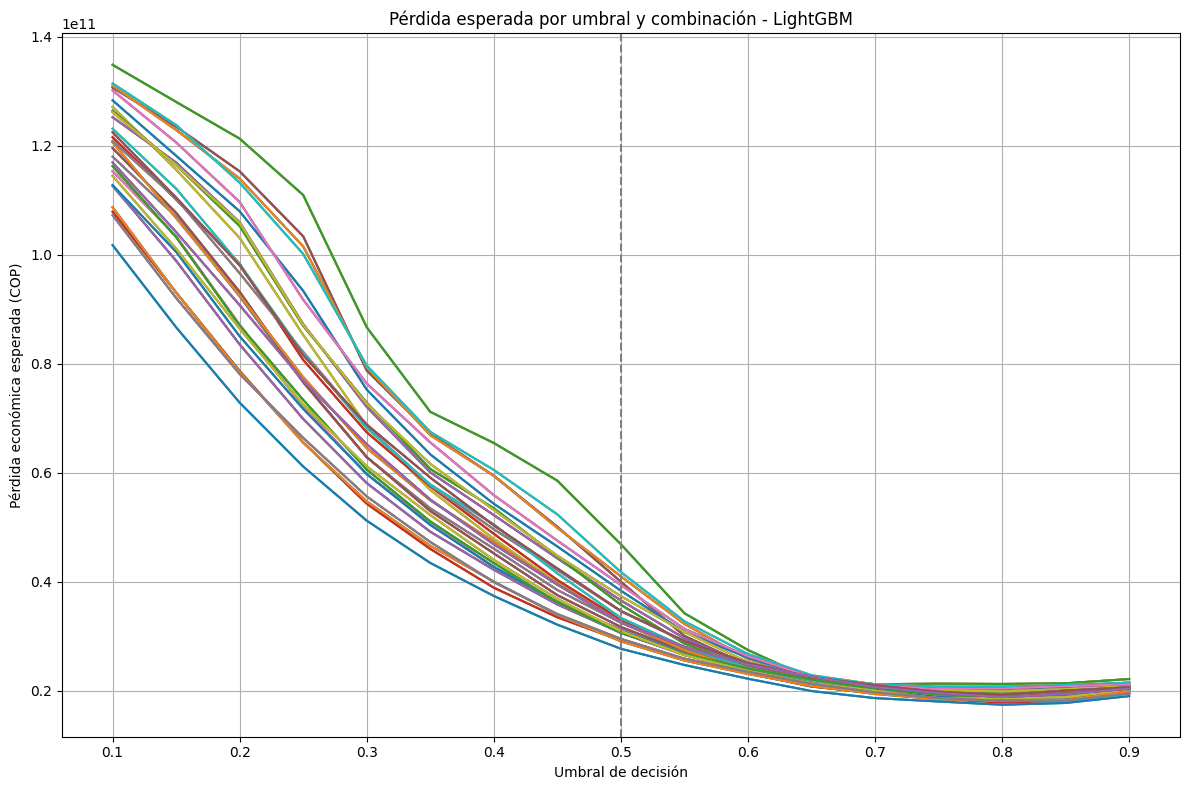

In [ ]:
# Hiperparámetros a probar
n_estimators_list = [100, 200,300]
learning_rates = [0.05, 0.1,0.15]
max_depths = [4, 6, -1]
subsamples = [0.6, 0.8, 1.0]

# Costos
costo_FN = veinte_por_ciento
costo_FP = salario_equipo_revision_medio

# Umbrales
umbrales = np.arange(0.1, 0.95, 0.05)
resultados_lgb = {}

# Todas las combinaciones posibles
combinaciones = list(product(n_estimators_list, learning_rates, max_depths, subsamples))

# Evaluar cada combinación
for n_est, lr, max_d, subsample in combinaciones:
    model = lgb.LGBMClassifier(
        n_estimators=n_est,
        learning_rate=lr,
        max_depth=max_d,
        subsample=subsample,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=42
    )
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    perdidas = []
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        perdida = (fn * costo_FN) + (fp * costo_FP)
        perdidas.append(perdida)

    etiqueta = f"LGB: est={n_est}, lr={lr}, depth={max_d}, sub={subsample}"
    resultados_lgb[etiqueta] = perdidas

# Graficar
plt.figure(figsize=(12, 8))
for nombre, perdidas in resultados_lgb.items():
    plt.plot(umbrales, perdidas, label=nombre)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada por umbral y combinación - LightGBM")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.grid(True)
plt.tight_layout()
plt.show()

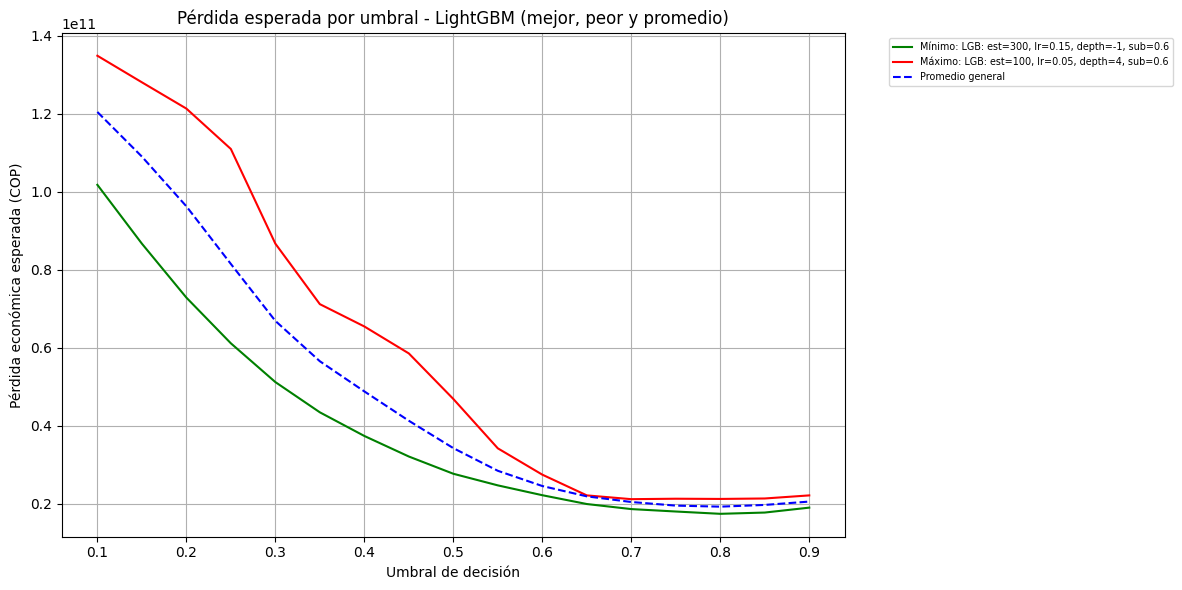

In [ ]:
# Paso 1: Calcular la pérdida total por modelo (sumatoria de cada lista de pérdidas)
suma_por_modelo_lgb = {k: sum(v) for k, v in resultados_lgb.items()}

# Paso 2: Identificar mejor y peor combinación
mejor_modelo_lgb = min(suma_por_modelo_lgb, key=suma_por_modelo_lgb.get)
peor_modelo_lgb = max(suma_por_modelo_lgb, key=suma_por_modelo_lgb.get)

# Paso 3: Calcular promedio de pérdidas por umbral (promedio fila por fila)
promedio_por_umbral_lgb = np.mean(np.array(list(resultados_lgb.values())), axis=0)

# Paso 4: Gráfica final
plt.figure(figsize=(12, 6))

plt.plot(umbrales, resultados_lgb[mejor_modelo_lgb], 'g-', label=f"Mínimo: {mejor_modelo_lgb}")
plt.plot(umbrales, resultados_lgb[peor_modelo_lgb], 'r-', label=f"Máximo: {peor_modelo_lgb}")
plt.plot(umbrales, promedio_por_umbral_lgb, 'b--', label="Promedio general")

plt.title("Pérdida esperada por umbral - LightGBM (mejor, peor y promedio)")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='x-small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Encontrar la combinación y umbral con menor pérdida en LightGBM
mejor_combinacion_lgb = None
mejor_umbral_lgb = None
mejor_perdida_lgb = float('inf')

for nombre, perdidas in resultados_lgb.items():
    idx_min = np.argmin(perdidas)
    if perdidas[idx_min] < mejor_perdida_lgb:
        mejor_perdida_lgb = perdidas[idx_min]
        mejor_combinacion_lgb = nombre
        mejor_umbral_lgb = umbrales[idx_min]

# Mostrar resultado óptimo
print("\nMejor combinación encontrada (LightGBM):")
print(f"Parámetros: {mejor_combinacion_lgb}")
print(f"Umbral óptimo: {mejor_umbral_lgb:.2f}")
print(f"Pérdida mínima estimada: ${mejor_perdida_lgb:,.0f} COP")



Mejor combinación encontrada (LightGBM):
Parámetros: LGB: est=300, lr=0.15, depth=-1, sub=0.6
Umbral óptimo: 0.80
Pérdida mínima estimada: $17,465,908,653 COP


In [ ]:
# Crear y entrenar el modelo LightGBM
model_LGB = lgb.LGBMClassifier(
    n_estimators=300,          # Número de árboles
    max_depth=-1,              # Sin límite de profundidad
    learning_rate=0.15,        # Tasa de aprendizaje
    subsample=0.6,             # Proporción de datos para cada árbol
    colsample_bytree=0.8,      # Proporción de características para cada árbol
    class_weight='balanced',   # Manejo de clases desbalanceadas
    random_state=42            # Para reproducibilidad
)

# Entrenar el modelo
model_LGB.fit(X_train, y_train)

# Definir el umbral deseado
umbral_lgb = 0.8  # Puedes cambiarlo según lo que quieras probar

# Predecir probabilidades
y_proba_LGB = model_LGB.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
y_pred_LGB_custom = (y_proba_LGB >= umbral_lgb).astype(int)

# Evaluación
print(f"\nEvaluación del modelo LightGBM con umbral = {umbral_lgb}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_LGB_custom, target_names=['No Adición', 'Adición']))

# Matriz de confusión
conf_matrix_LGB = confusion_matrix(y_test, y_pred_LGB_custom)
print("\nMatriz de confusión:")
print(conf_matrix_LGB)

# Definir costos
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = salario_equipo_revision_medio               # Revisar innecesariamente un contrato

# Obtener métricas de la matriz de confusión
tnlgb, fplgb, fnlgb, tplgb = conf_matrix_LGB.ravel()

# Calcular pérdida económica total
perdida_total_lgb = (fnlgb * costo_FN) + (fplgb * costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbral_lgb}: ${perdida_total_lgb:,.0f} COP")
print(f"FN = {fnlgb}, FP = {fplgb}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 14468, number of negative: 112877
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026079 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1888
[LightGBM] [Info] Number of data points in the train set: 127345, number of used features: 307
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

Evaluación del modelo LightGBM con umbral = 0.8

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       0.94      0.97      0.95     28350
     Adición       0.67      0.50      0.57      3486

    accuracy                           0.92     31836
   macro avg       0.80      0.74      0.76     31836
weighted avg       0.91      0.92      0.91     31836


Matriz de confusión:


In [ ]:
Costoporcontratolgb=perdida_total_lgb/len(X_test)
Costoporcontratolgb

548621.3297102074

In [ ]:
# Rango de umbrales
umbrales = np.arange(0.05, 0.95, 0.01)

costos_lgb = []
cambios_lgb = [0]
fn_list_lgb = []
fp_list_lgb = []

# Evaluar cada umbral
for umbral in umbrales:
    y_pred = (y_proba_LGB >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    costo = (fn * costo_FN) + (fp * costo_FP)
    costos_lgb.append(costo)
    fn_list_lgb.append(fn)
    fp_list_lgb.append(fp)

# Cambios porcentuales entre umbrales
for i in range(1, len(costos_lgb)):
    cambio = (costos_lgb[i] - costos_lgb[i-1]) / costos_lgb[i-1] * 100
    cambios_lgb.append(cambio)

# Tabla resumen
tabla_sensibilidad_lgb = pd.DataFrame({
    'Umbral': umbrales,
    'Costo Total': costos_lgb,
    'Cambio % vs anterior': cambios_lgb,
    'FN': fn_list_lgb,
    'FP': fp_list_lgb
})

pd.set_option('display.float_format', '{:,.2f}'.format)
display(tabla_sensibilidad_lgb.head(10))  # Puedes cambiar a .tail() o mostrar todo

# Sensibilidad media (absoluta)
sensibilidad_media_lgb = np.mean(np.abs(tabla_sensibilidad_lgb['Cambio % vs anterior'][1:]))  # sin el primero
print(f"Sensibilidad media: {sensibilidad_media_lgb:.2f}% por cada 1% de cambio en el umbral")


,Umbral,Costo Total,Cambio % vs anterior,FN,FP
0,0.05,"116,548,927,485.75",0.00,30,21782
1,0.06,"113,597,050,418.31",-2.53,36,21221
2,0.07,"110,846,092,421.68",-2.42,41,20699
3,0.08,"107,994,389,715.37",-2.57,49,20154
4,0.09,"104,662,036,740.46",-3.09,57,19519
5,0.10,"101,799,082,568.54",-2.74,70,18965
6,0.11,"98,580,903,476.68",-3.16,79,18350
7,0.12,"95,799,353,933.98",-2.82,90,17814
8,0.13,"92,638,624,734.95",-3.30,101,17207
9,0.14,"89,693,540,031.21",-3.18,113,16639


Sensibilidad media: 2.31% por cada 1% de cambio en el umbral


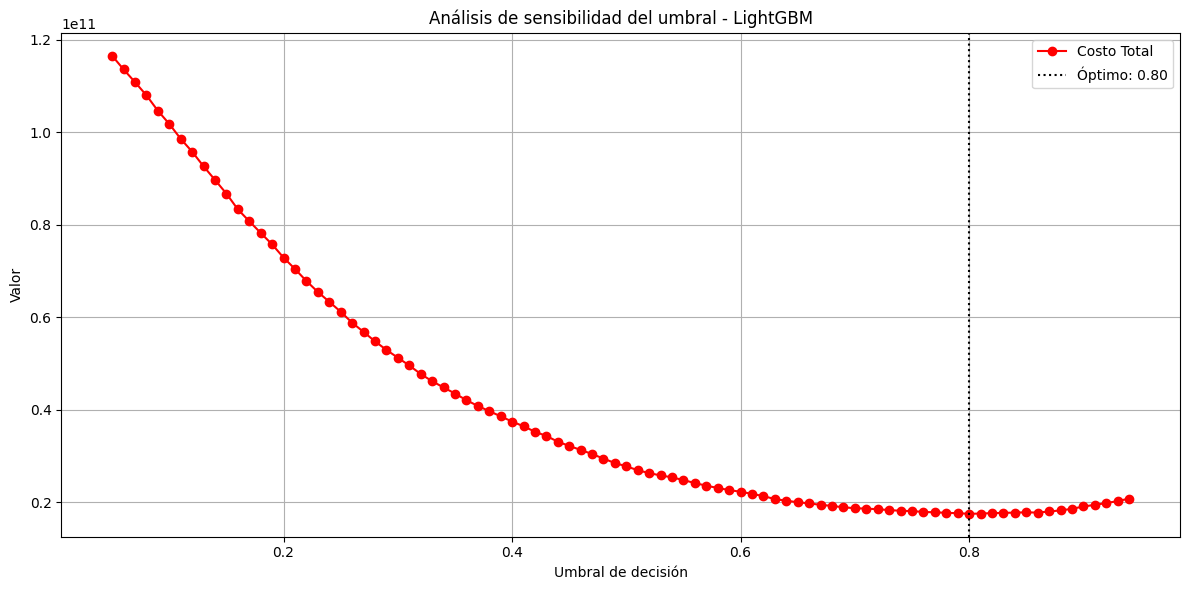

In [ ]:
# Encontrar umbral de menor costo
idx_min_lgb = np.argmin(costos_lgb)
mejor_umbral_lgb = umbrales[idx_min_lgb]
mejor_costo_lgb = costos_lgb[idx_min_lgb]

plt.figure(figsize=(12, 6))

# Línea de costo
plt.plot(umbrales, costos_lgb, 'o-r', label='Costo Total')



# Umbral óptimo
plt.axvline(mejor_umbral_lgb, color='black', linestyle=':', label=f'Óptimo: {mejor_umbral_lgb:.2f}')

plt.title("Análisis de sensibilidad del umbral - LightGBM")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Salario alto

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 14468, number of negative: 112877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008097 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1888
[LightGBM] [Info] Number of data points in the train set: 127345, number of used features: 307
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

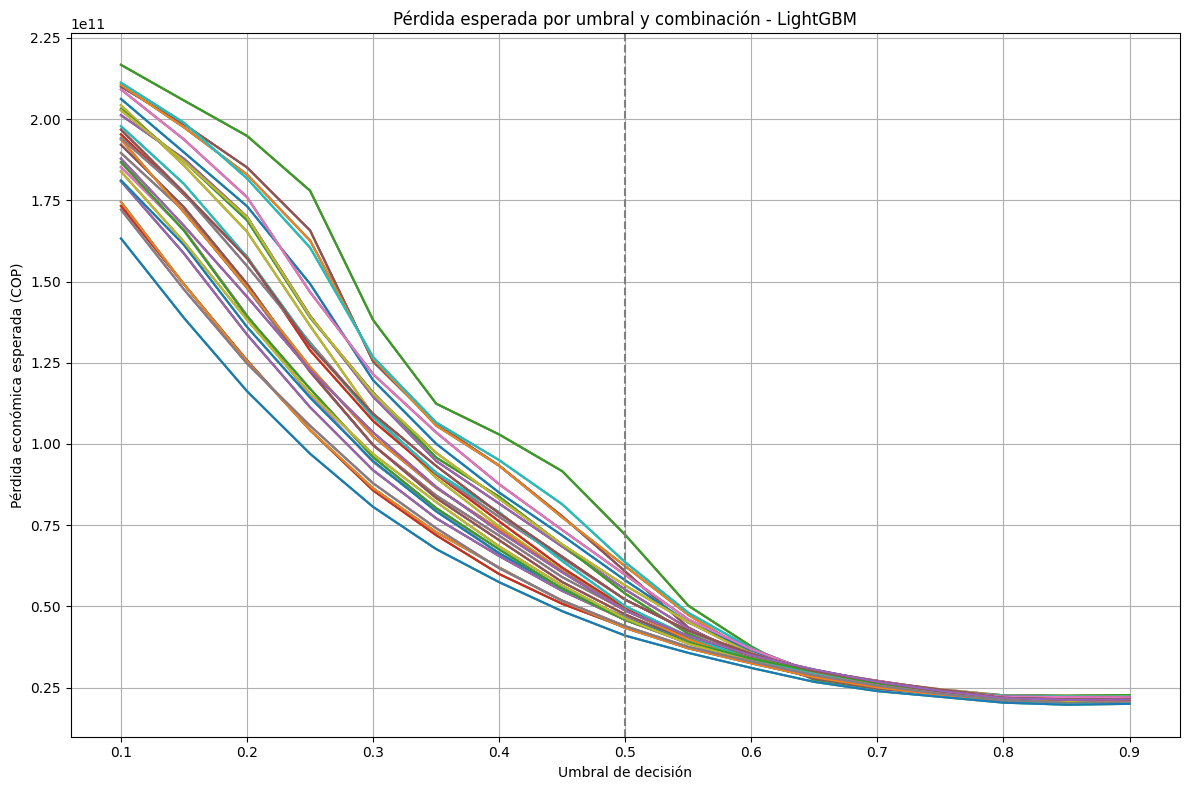

In [ ]:
# Hiperparámetros a probar
n_estimators_list = [100, 200,300]
learning_rates = [0.05, 0.1,0.15]
max_depths = [4, 6, -1]
subsamples = [0.6, 0.8, 1.0]

# Costos
costo_FN = veinte_por_ciento
costo_FP = salario_equipo_revision_alto

# Umbrales
umbrales = np.arange(0.1, 0.95, 0.05)
resultados_lgb = {}

# Todas las combinaciones posibles
combinaciones = list(product(n_estimators_list, learning_rates, max_depths, subsamples))

# Evaluar cada combinación
for n_est, lr, max_d, subsample in combinaciones:
    model = lgb.LGBMClassifier(
        n_estimators=n_est,
        learning_rate=lr,
        max_depth=max_d,
        subsample=subsample,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=42
    )
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    perdidas = []
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        perdida = (fn * costo_FN) + (fp * costo_FP)
        perdidas.append(perdida)

    etiqueta = f"LGB: est={n_est}, lr={lr}, depth={max_d}, sub={subsample}"
    resultados_lgb[etiqueta] = perdidas

# Graficar
plt.figure(figsize=(12, 8))
for nombre, perdidas in resultados_lgb.items():
    plt.plot(umbrales, perdidas, label=nombre)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada por umbral y combinación - LightGBM")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.grid(True)
plt.tight_layout()
plt.show()

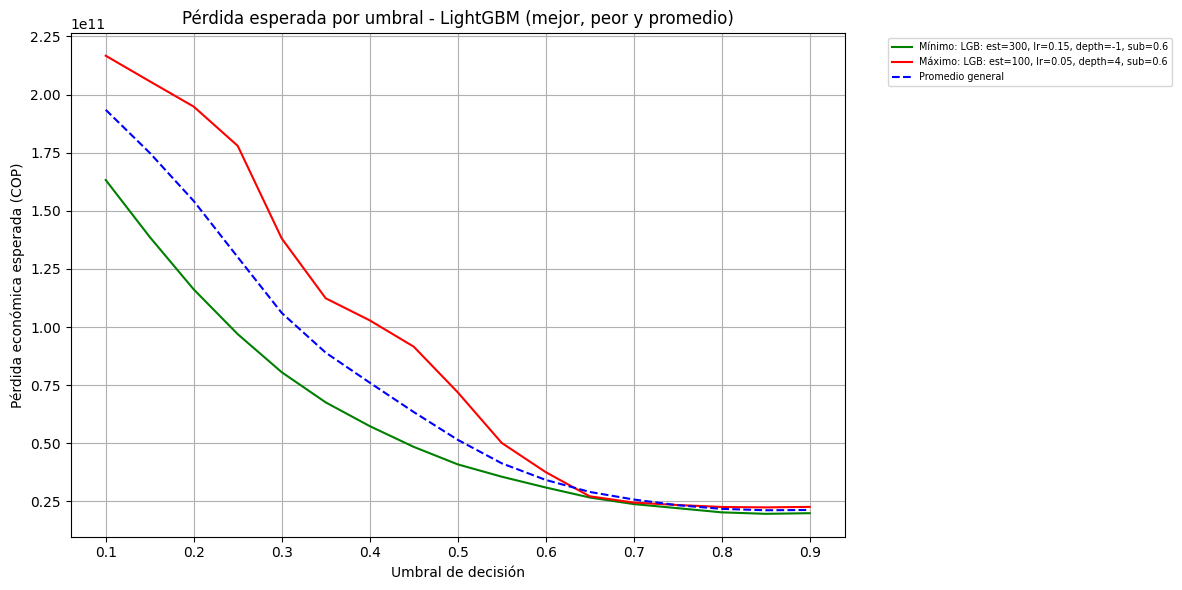

In [ ]:
# Paso 1: Calcular la pérdida total por modelo (sumatoria de cada lista de pérdidas)
suma_por_modelo_lgb = {k: sum(v) for k, v in resultados_lgb.items()}

# Paso 2: Identificar mejor y peor combinación
mejor_modelo_lgb = min(suma_por_modelo_lgb, key=suma_por_modelo_lgb.get)
peor_modelo_lgb = max(suma_por_modelo_lgb, key=suma_por_modelo_lgb.get)

# Paso 3: Calcular promedio de pérdidas por umbral (promedio fila por fila)
promedio_por_umbral_lgb = np.mean(np.array(list(resultados_lgb.values())), axis=0)

# Paso 4: Gráfica final
plt.figure(figsize=(12, 6))

plt.plot(umbrales, resultados_lgb[mejor_modelo_lgb], 'g-', label=f"Mínimo: {mejor_modelo_lgb}")
plt.plot(umbrales, resultados_lgb[peor_modelo_lgb], 'r-', label=f"Máximo: {peor_modelo_lgb}")
plt.plot(umbrales, promedio_por_umbral_lgb, 'b--', label="Promedio general")

plt.title("Pérdida esperada por umbral - LightGBM (mejor, peor y promedio)")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='x-small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Encontrar la combinación y umbral con menor pérdida en LightGBM
mejor_combinacion_lgb = None
mejor_umbral_lgb = None
mejor_perdida_lgb = float('inf')

for nombre, perdidas in resultados_lgb.items():
    idx_min = np.argmin(perdidas)
    if perdidas[idx_min] < mejor_perdida_lgb:
        mejor_perdida_lgb = perdidas[idx_min]
        mejor_combinacion_lgb = nombre
        mejor_umbral_lgb = umbrales[idx_min]

# Mostrar resultado óptimo
print("\nMejor combinación encontrada (LightGBM):")
print(f"Parámetros: {mejor_combinacion_lgb}")
print(f"Umbral óptimo: {mejor_umbral_lgb:.2f}")
print(f"Pérdida mínima estimada: ${mejor_perdida_lgb:,.0f} COP")



Mejor combinación encontrada (LightGBM):
Parámetros: LGB: est=300, lr=0.15, depth=-1, sub=0.6
Umbral óptimo: 0.85
Pérdida mínima estimada: $19,698,819,439 COP


In [ ]:
# Crear y entrenar el modelo LightGBM
model_LGB = lgb.LGBMClassifier(
    n_estimators=300,          # Número de árboles
    max_depth=-1,              # Sin límite de profundidad
    learning_rate=0.15,        # Tasa de aprendizaje
    subsample=0.6,             # Proporción de datos para cada árbol
    colsample_bytree=0.8,      # Proporción de características para cada árbol
    class_weight='balanced',   # Manejo de clases desbalanceadas
    random_state=42            # Para reproducibilidad
)

# Entrenar el modelo
model_LGB.fit(X_train, y_train)

# Definir el umbral deseado
umbral_lgb = 0.85  # Puedes cambiarlo según lo que quieras probar

# Predecir probabilidades
y_proba_LGB = model_LGB.predict_proba(X_test)[:, 1]

# Aplicar umbral personalizado
y_pred_LGB_custom = (y_proba_LGB >= umbral_lgb).astype(int)

# Evaluación
print(f"\nEvaluación del modelo LightGBM con umbral = {umbral_lgb}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_LGB_custom, target_names=['No Adición', 'Adición']))

# Matriz de confusión
conf_matrix_LGB = confusion_matrix(y_test, y_pred_LGB_custom)
print("\nMatriz de confusión:")
print(conf_matrix_LGB)

# Definir costos
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = salario_equipo_revision_alto               # Revisar innecesariamente un contrato

# Obtener métricas de la matriz de confusión
tnlgb, fplgb, fnlgb, tplgb = conf_matrix_LGB.ravel()

# Calcular pérdida económica total
perdida_total_lgb = (fnlgb * costo_FN) + (fplgb * costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbral_lgb}: ${perdida_total_lgb:,.0f} COP")
print(f"FN = {fnlgb}, FP = {fplgb}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 14468, number of negative: 112877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008480 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1888
[LightGBM] [Info] Number of data points in the train set: 127345, number of used features: 307
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

Evaluación del modelo LightGBM con umbral = 0.85

Reporte de clasificación:
              precision    recall  f1-score   support

  No Adición       0.93      0.98      0.96     28350
     Adición       0.72      0.43      0.54      3486

    accuracy                           0.92     31836
   macro avg       0.83      0.70      0.75     31836
weighted avg

In [ ]:
Costoporcontratolgb=perdida_total_lgb/len(X_test)
Costoporcontratolgb

618759.2486131164

In [ ]:
# Rango de umbrales
umbrales = np.arange(0.05, 0.95, 0.01)

costos_lgb = []
cambios_lgb = [0]
fn_list_lgb = []
fp_list_lgb = []

# Evaluar cada umbral
for umbral in umbrales:
    y_pred = (y_proba_LGB >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    costo = (fn * costo_FN) + (fp * costo_FP)
    costos_lgb.append(costo)
    fn_list_lgb.append(fn)
    fp_list_lgb.append(fp)

# Cambios porcentuales entre umbrales
for i in range(1, len(costos_lgb)):
    cambio = (costos_lgb[i] - costos_lgb[i-1]) / costos_lgb[i-1] * 100
    cambios_lgb.append(cambio)

# Tabla resumen
tabla_sensibilidad_lgb = pd.DataFrame({
    'Umbral': umbrales,
    'Costo Total': costos_lgb,
    'Cambio % vs anterior': cambios_lgb,
    'FN': fn_list_lgb,
    'FP': fp_list_lgb
})

pd.set_option('display.float_format', '{:,.2f}'.format)
display(tabla_sensibilidad_lgb.head(10))  # Puedes cambiar a .tail() o mostrar todo

# Sensibilidad media (absoluta)
sensibilidad_alto_lgb = np.mean(np.abs(tabla_sensibilidad_lgb['Cambio % vs anterior'][1:]))  # sin el primero
print(f"Sensibilidad alto: {sensibilidad_alto_lgb:.2f}% por cada 1% de cambio en el umbral")


,Umbral,Costo Total,Cambio % vs anterior,FN,FP
0,0.05,"187,138,723,769.73",0.00,30,21782
1,0.06,"182,368,791,624.00",-2.55,36,21221
2,0.07,"177,926,167,404.79",-2.44,41,20699
3,0.08,"173,308,261,458.43",-2.60,49,20154
4,0.09,"167,918,038,653.37",-3.11,57,19519
5,0.10,"163,259,714,582.39",-2.77,70,18965
6,0.11,"158,048,480,458.18",-3.19,79,18350
7,0.12,"153,529,894,334.44",-2.86,90,17814
8,0.13,"148,402,036,022.18",-3.34,101,17207
9,0.14,"143,616,211,060.92",-3.22,113,16639


Sensibilidad alto: 2.61% por cada 1% de cambio en el umbral


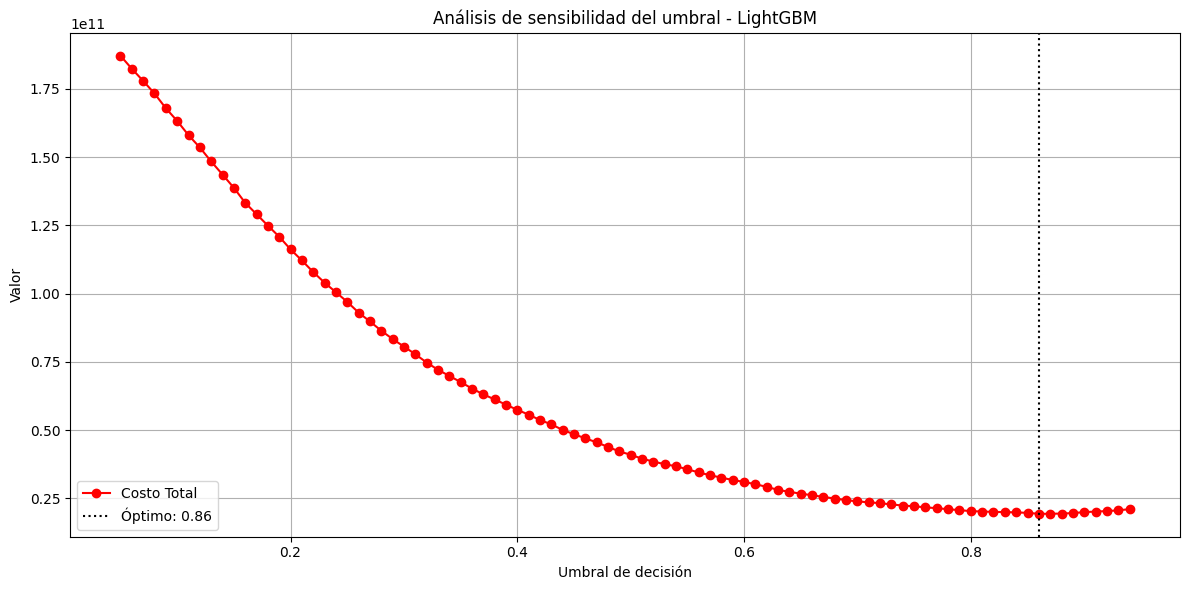

In [ ]:
# Encontrar umbral de menor costo
idx_min_lgb = np.argmin(costos_lgb)
mejor_umbral_lgb = umbrales[idx_min_lgb]
mejor_costo_lgb = costos_lgb[idx_min_lgb]

plt.figure(figsize=(12, 6))

# Línea de costo
plt.plot(umbrales, costos_lgb, 'o-r', label='Costo Total')


# Umbral óptimo
plt.axvline(mejor_umbral_lgb, color='black', linestyle=':', label=f'Óptimo: {mejor_umbral_lgb:.2f}')

plt.title("Análisis de sensibilidad del umbral - LightGBM")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Redes neuronales

### Salario bajo

In [ ]:
# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hiperparámetros a combinar
n_neurons_1_list = [32, 64,128]
n_neurons_2_list = [16, 32,64]
learning_rates = [0.001, 0.005,0.01]
epochs = 50
batch_size = 64
umbrales = np.arange(0.1, 0.95, 0.05)

# Costos
costo_FN = veinte_por_ciento
costo_FP = salario_equipo_revision_bajo

# Guardar resultados
resultados_nn = {}

# Combinaciones
combinaciones = list(product(n_neurons_1_list, n_neurons_2_list, learning_rates))

for n1, n2, lr in combinaciones:
    model = Sequential([
        Dense(n1, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dense(n1, activation='relu'),
        Dense(n2, activation='relu'),
        Dense(n2, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    model.fit(X_train_scaled, y_train,
              validation_data=(X_test_scaled, y_test),
              epochs=epochs,
              batch_size=batch_size,
              verbose=0)
    
    y_proba = model.predict(X_test_scaled)
    perdidas = []
    
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        perdida = (fn * costo_FN) + (fp * costo_FP)
        perdidas.append(perdida)

    nombre = f"NN n1={n1}, n2={n2}, lr={lr}"
    resultados_nn[nombre] = perdidas

# Graficar pérdidas
plt.figure(figsize=(12, 7))
for nombre, perdidas in resultados_nn.items():
    plt.plot(umbrales, perdidas, label=nombre)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada vs Umbral - Redes Neuronales")
plt.xlabel("Umbral")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Paso 1: Sumar pérdidas por combinación para hallar mejor y peor
suma_por_modelo_nn = {k: sum(v) for k, v in resultados_nn.items()}

mejor_modelo_nn = min(suma_por_modelo_nn, key=suma_por_modelo_nn.get)
peor_modelo_nn = max(suma_por_modelo_nn, key=suma_por_modelo_nn.get)

# Paso 2: Calcular promedio por umbral (punto a punto)
promedio_por_umbral_nn = np.mean(np.array(list(resultados_nn.values())), axis=0)

# Paso 3: Graficar
plt.figure(figsize=(12, 6))

plt.plot(umbrales, resultados_nn[mejor_modelo_nn], 'g-', label=f"Mínimo: {mejor_modelo_nn}")
plt.plot(umbrales, resultados_nn[peor_modelo_nn], 'r-', label=f"Máximo: {peor_modelo_nn}")
plt.plot(umbrales, promedio_por_umbral_nn, 'b--', label="Promedio general")

plt.title("Pérdida esperada por umbral - Red Neuronal (mejor, peor y promedio)")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='x-small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Encontrar la combinación y umbral con menor pérdida en la red neuronal
mejor_combinacion_nn = None
mejor_umbral_nn = None
mejor_perdida_nn = float('inf')

for nombre, perdidas in resultados_nn.items():
    idx_min = np.argmin(perdidas)
    if perdidas[idx_min] < mejor_perdida_nn:
        mejor_perdida_nn = perdidas[idx_min]
        mejor_combinacion_nn = nombre
        mejor_umbral_nn = umbrales[idx_min]

# Mostrar resultado óptimo
print("\nMejor combinación encontrada (Red Neuronal):")
print(f"Parámetros: {mejor_combinacion_nn}")
print(f"Umbral óptimo: {mejor_umbral_nn:.2f}")
print(f"Pérdida mínima estimada: ${mejor_perdida_nn:,.0f} COP")


In [ ]:
# Parámetros
n1 = 32
n2 = 64
learning_rate = 0.005
epochs = 50
batch_size = 64
umbral_nn = 0.45  # Umbral para clasificación

# Crear el modelo
model_nn = Sequential([
    Dense(n1, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(n1, activation='relu'),
    Dense(n2, activation='relu'),
    Dense(n2, activation='relu'),
    Dense(1, activation='sigmoid')  # Salida binaria
])

# Compilar el modelo
model_nn.compile(optimizer=Adam(learning_rate=learning_rate),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# Entrenar el modelo
history = model_nn.fit(X_train_scaled, y_train,
                       validation_data=(X_test_scaled, y_test),
                       epochs=epochs,
                       batch_size=batch_size,
                       verbose=1)

# Evaluar el modelo
loss, accuracy = model_nn.evaluate(X_test_scaled, y_test)
print(f"Loss: {loss}, Accuracy: {accuracy}")

# Predecir probabilidades
y_proba_nn = model_nn.predict(X_test_scaled)

# Aplicar el umbral personalizado
y_pred_nn_custom = (y_proba_nn >= umbral_nn).astype(int)

# Evaluación
print(f"\nEvaluación del modelo de red neuronal con umbral = {umbral_nn}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_nn_custom, target_names=['No Adición', 'Adición']))

# Matriz de confusión
conf_matrix_nn = confusion_matrix(y_test, y_pred_nn_custom)
print("\nMatriz de confusión:")
print(conf_matrix_nn)

# Calcular pérdida económica total
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = salario_equipo_revision_bajo               # Revisar innecesariamente un contrato
tn_nn, fp_nn, fn_nn, tp_nn = conf_matrix_nn.ravel()
perdida_total_nn = (fn_nn * costo_FN) + (fp_nn * costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbral_nn}: ${perdida_total_nn:,.0f} COP")

In [ ]:
Costoporcontratonn=perdida_total_nn/len(X_test)
Costoporcontratonn

In [ ]:
# Rango de umbrales a evaluar
umbrales = np.arange(0.05, 0.95, 0.01)

costos_nn = []
cambios_nn = [0]
fn_list_nn = []
fp_list_nn = []

# Evaluar cada umbral
for umbral in umbrales:
    y_pred = (y_proba_nn >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    costo = (fn * costo_FN) + (fp * costo_FP)
    costos_nn.append(costo)
    fn_list_nn.append(fn)
    fp_list_nn.append(fp)

# Cambios porcentuales
for i in range(1, len(costos_nn)):
    cambio = (costos_nn[i] - costos_nn[i-1]) / costos_nn[i-1] * 100
    cambios_nn.append(cambio)

# Crear tabla
tabla_sensibilidad_nn = pd.DataFrame({
    'Umbral': umbrales,
    'Costo Total': costos_nn,
    'Cambio % vs anterior': cambios_nn,
    'FN': fn_list_nn,
    'FP': fp_list_nn
})

pd.set_option('display.float_format', '{:,.2f}'.format)
display(tabla_sensibilidad_nn.head(10))  # O .tail(), o todo

# Sensibilidad media (absoluta)
sensibilidad_bajo_nn = np.mean(np.abs(tabla_sensibilidad_nn['Cambio % vs anterior'][1:]))  # sin el primero
print(f"Sensibilidad bajo: {sensibilidad_bajo_nn:.2f}% por cada 1% de cambio en el umbral")


In [ ]:
# Encontrar umbral óptimo
idx_min_nn = np.argmin(costos_nn)
mejor_umbral_nn = umbrales[idx_min_nn]
mejor_costo_nn = costos_nn[idx_min_nn]

plt.figure(figsize=(12, 6))

# Costo
plt.plot(umbrales, costos_nn, 'o-r', label='Costo Total')


# Línea de umbral óptimo
plt.axvline(mejor_umbral_nn, color='black', linestyle=':', label=f'Óptimo: {mejor_umbral_nn:.2f}')

plt.title("Análisis de sensibilidad del umbral - Red Neuronal")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Salario medio

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


995/995 ━━━━━━━━━━━━━━━━━━━━ 1s 469us/step


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


995/995 ━━━━━━━━━━━━━━━━━━━━ 0s 462us/step


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

995/995 ━━━━━━━━━━━━━━━━━━━━ 1s 911us/step


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


995/995 ━━━━━━━━━━━━━━━━━━━━ 1s 540us/step


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


995/995 ━━━━━━━━━━━━━━━━━━━━ 1s 491us/step


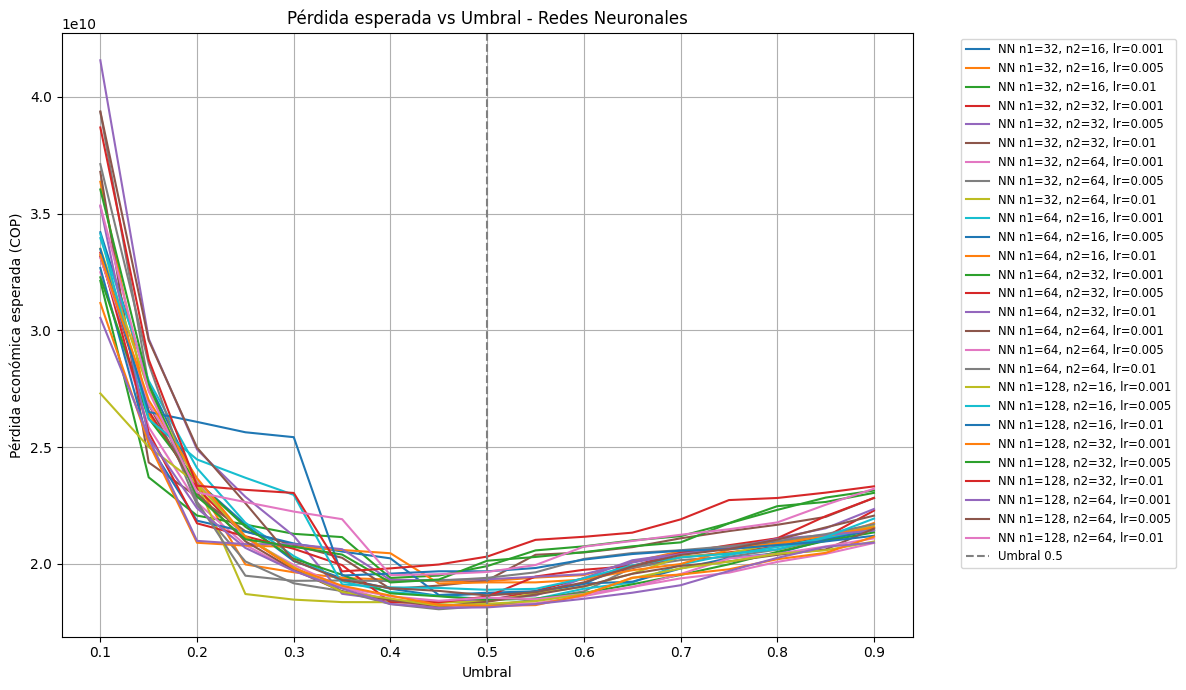

In [ ]:
# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hiperparámetros a combinar
n_neurons_1_list = [32, 64,128]
n_neurons_2_list = [16, 32,64]
learning_rates = [0.001, 0.005,0.01]
epochs = 50
batch_size = 64
umbrales = np.arange(0.1, 0.95, 0.05)

# Costos
costo_FN = veinte_por_ciento
costo_FP = salario_equipo_revision_medio

# Guardar resultados
resultados_nn = {}

# Combinaciones
combinaciones = list(product(n_neurons_1_list, n_neurons_2_list, learning_rates))

for n1, n2, lr in combinaciones:
    model = Sequential([
        Dense(n1, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dense(n1, activation='relu'),
        Dense(n2, activation='relu'),
        Dense(n2, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    model.fit(X_train_scaled, y_train,
              validation_data=(X_test_scaled, y_test),
              epochs=epochs,
              batch_size=batch_size,
              verbose=0)
    
    y_proba = model.predict(X_test_scaled)
    perdidas = []
    
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        perdida = (fn * costo_FN) + (fp * costo_FP)
        perdidas.append(perdida)

    nombre = f"NN n1={n1}, n2={n2}, lr={lr}"
    resultados_nn[nombre] = perdidas

# Graficar pérdidas
plt.figure(figsize=(12, 7))
for nombre, perdidas in resultados_nn.items():
    plt.plot(umbrales, perdidas, label=nombre)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada vs Umbral - Redes Neuronales")
plt.xlabel("Umbral")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Paso 1: Sumar pérdidas por combinación para hallar mejor y peor
suma_por_modelo_nn = {k: sum(v) for k, v in resultados_nn.items()}

mejor_modelo_nn = min(suma_por_modelo_nn, key=suma_por_modelo_nn.get)
peor_modelo_nn = max(suma_por_modelo_nn, key=suma_por_modelo_nn.get)

# Paso 2: Calcular promedio por umbral (punto a punto)
promedio_por_umbral_nn = np.mean(np.array(list(resultados_nn.values())), axis=0)

# Paso 3: Graficar
plt.figure(figsize=(12, 6))

plt.plot(umbrales, resultados_nn[mejor_modelo_nn], 'g-', label=f"🟢 Mínimo: {mejor_modelo_nn}")
plt.plot(umbrales, resultados_nn[peor_modelo_nn], 'r-', label=f"🔴 Máximo: {peor_modelo_nn}")
plt.plot(umbrales, promedio_por_umbral_nn, 'b--', label="🔵 Promedio general")

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada por umbral - Red Neuronal (mejor, peor y promedio)")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='x-small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Encontrar la combinación y umbral con menor pérdida en la red neuronal
mejor_combinacion_nn = None
mejor_umbral_nn = None
mejor_perdida_nn = float('inf')

for nombre, perdidas in resultados_nn.items():
    idx_min = np.argmin(perdidas)
    if perdidas[idx_min] < mejor_perdida_nn:
        mejor_perdida_nn = perdidas[idx_min]
        mejor_combinacion_nn = nombre
        mejor_umbral_nn = umbrales[idx_min]

# Mostrar resultado óptimo
print("\nMejor combinación encontrada (Red Neuronal):")
print(f"Parámetros: {mejor_combinacion_nn}")
print(f"Umbral óptimo: {mejor_umbral_nn:.2f}")
print(f"Pérdida mínima estimada: ${mejor_perdida_nn:,.0f} COP")



Mejor combinación encontrada (Red Neuronal):
Parámetros: NN n1=32, n2=64, lr=0.005
Umbral óptimo: 0.45
Pérdida mínima estimada: $18,056,335,831 COP


In [ ]:
# Parámetros
n1 = 32
n2 = 64
learning_rate = 0.005
epochs = 50
batch_size = 64
umbral_nn = 0.45  # Umbral para clasificación

# Crear el modelo
model_nn = Sequential([
    Dense(n1, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(n1, activation='relu'),
    Dense(n2, activation='relu'),
    Dense(n2, activation='relu'),
    Dense(1, activation='sigmoid')  # Salida binaria
])

# Compilar el modelo
model_nn.compile(optimizer=Adam(learning_rate=learning_rate),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# Entrenar el modelo
history = model_nn.fit(X_train_scaled, y_train,
                       validation_data=(X_test_scaled, y_test),
                       epochs=epochs,
                       batch_size=batch_size,
                       verbose=1)

# Evaluar el modelo
loss, accuracy = model_nn.evaluate(X_test_scaled, y_test)
print(f"Loss: {loss}, Accuracy: {accuracy}")

# Predecir probabilidades
y_proba_nn = model_nn.predict(X_test_scaled)

# Aplicar el umbral personalizado
y_pred_nn_custom = (y_proba_nn >= umbral_nn).astype(int)

# Evaluación
print(f"\nEvaluación del modelo de red neuronal con umbral = {umbral_nn}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_nn_custom, target_names=['No Adición', 'Adición']))

# Matriz de confusión
conf_matrix_nn = confusion_matrix(y_test, y_pred_nn_custom)
print("\nMatriz de confusión:")
print(conf_matrix_nn)

# Calcular pérdida económica total
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = salario_equipo_revision_medio               # Revisar innecesariamente un contrato
tn_nn, fp_nn, fn_nn, tp_nn = conf_matrix_nn.ravel()
perdida_total_nn = (fn_nn * costo_FN) + (fp_nn * costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbral_nn}: ${perdida_total_nn:,.0f} COP")

Epoch 1/50


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1990/1990 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8986 - loss: 0.2852 - val_accuracy: 0.9099 - val_loss: 0.2521
Epoch 2/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9055 - loss: 0.2560 - val_accuracy: 0.9088 - val_loss: 0.2452
Epoch 3/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9077 - loss: 0.2452 - val_accuracy: 0.9095 - val_loss: 0.2429
Epoch 4/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9092 - loss: 0.2396 - val_accuracy: 0.9118 - val_loss: 0.2419
Epoch 5/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9083 - loss: 0.2377 - val_accuracy: 0.9110 - val_loss: 0.2451
Epoch 6/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9120 - loss: 0.2306 - val_accuracy: 0.9111 - val_loss: 0.2402
Epoch 7/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9121 - loss: 0.2318 - val_accuracy: 0.9114 - val_loss: 0.2367
Epoch 8/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9142 - loss: 0.2267 - val_accurac

In [ ]:
Costoporcontratonn=perdida_total_nn/len(X_test)
Costoporcontratonn

597446.659334927

In [ ]:
# Rango de umbrales a evaluar
umbrales = np.arange(0.05, 0.95, 0.01)

costos_nn = []
cambios_nn = [0]
fn_list_nn = []
fp_list_nn = []

# Evaluar cada umbral
for umbral in umbrales:
    y_pred = (y_proba_nn >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    costo = (fn * costo_FN) + (fp * costo_FP)
    costos_nn.append(costo)
    fn_list_nn.append(fn)
    fp_list_nn.append(fp)

# Cambios porcentuales
for i in range(1, len(costos_nn)):
    cambio = (costos_nn[i] - costos_nn[i-1]) / costos_nn[i-1] * 100
    cambios_nn.append(cambio)

# Crear tabla
tabla_sensibilidad_nn = pd.DataFrame({
    'Umbral': umbrales,
    'Costo Total': costos_nn,
    'Cambio % vs anterior': cambios_nn,
    'FN': fn_list_nn,
    'FP': fp_list_nn
})

pd.set_option('display.float_format', '{:,.2f}'.format)
display(tabla_sensibilidad_nn.head(10))  # O .tail(), o todo

# Sensibilidad media (absoluta)
sensibilidad_media_nn = np.mean(np.abs(tabla_sensibilidad_nn['Cambio % vs anterior'][1:]))  # sin el primero
print(f"Sensibilidad media: {sensibilidad_media_nn:.2f}% por cada 1% de cambio en el umbral")



,Umbral,Costo Total,Cambio % vs anterior,FN,FP
0,0.05,"63,152,968,297.77",0.00,374,11601
1,0.06,"57,163,053,653.93",-9.48,438,10360
2,0.07,"51,707,027,927.85",-9.54,484,9247
3,0.08,"47,012,610,299.20",-9.08,550,8252
4,0.09,"42,298,629,698.65",-10.03,619,7249
5,0.10,"38,881,933,595.76",-8.08,686,6498
6,0.11,"35,947,587,424.89",-7.55,728,5875
7,0.12,"32,963,390,415.33",-8.30,800,5200
8,0.13,"30,882,735,912.70",-6.31,854,4724
9,0.14,"29,006,180,364.81",-6.08,894,4307


Sensibilidad media: 1.64% por cada 1% de cambio en el umbral


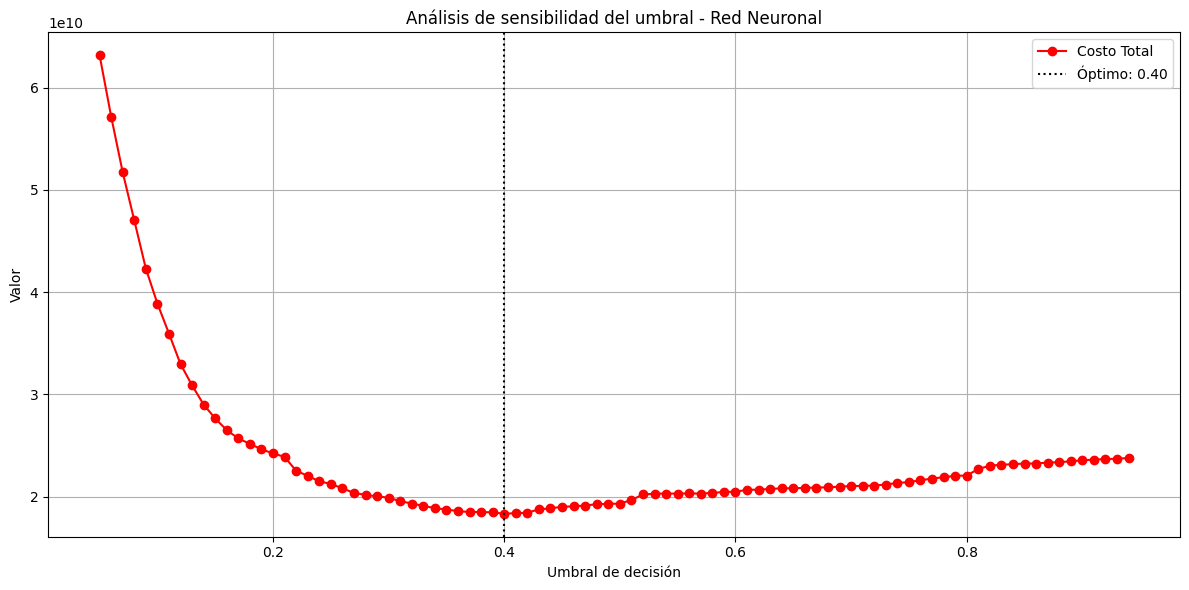

In [ ]:
# Encontrar umbral óptimo
idx_min_nn = np.argmin(costos_nn)
mejor_umbral_nn = umbrales[idx_min_nn]
mejor_costo_nn = costos_nn[idx_min_nn]

plt.figure(figsize=(12, 6))

# Costo
plt.plot(umbrales, costos_nn, 'o-r', label='Costo Total')


# Línea de umbral óptimo
plt.axvline(mejor_umbral_nn, color='black', linestyle=':', label=f'Óptimo: {mejor_umbral_nn:.2f}')

plt.title("Análisis de sensibilidad del umbral - Red Neuronal")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Salario Alto

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


995/995 ━━━━━━━━━━━━━━━━━━━━ 1s 989us/step


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


995/995 ━━━━━━━━━━━━━━━━━━━━ 1s 665us/step


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

995/995 ━━━━━━━━━━━━━━━━━━━━ 1s 472us/step


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


995/995 ━━━━━━━━━━━━━━━━━━━━ 1s 474us/step


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


995/995 ━━━━━━━━━━━━━━━━━━━━ 1s 481us/step


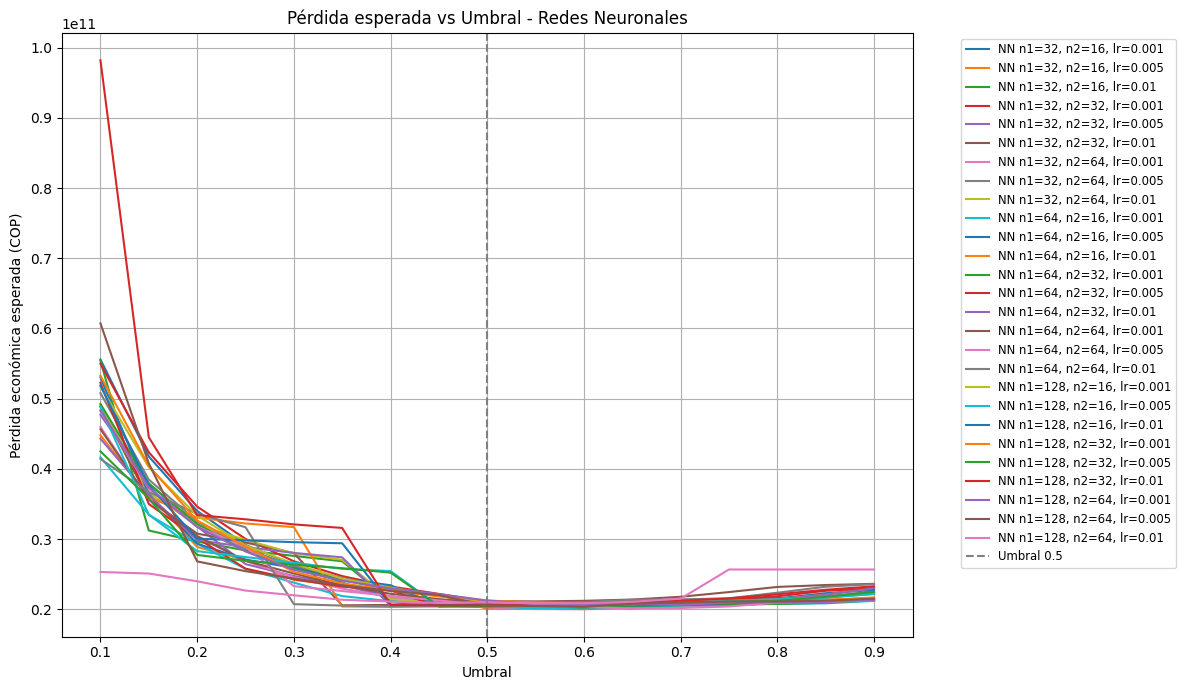

In [ ]:
# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hiperparámetros a combinar
n_neurons_1_list = [32, 64,128]
n_neurons_2_list = [16, 32,64]
learning_rates = [0.001, 0.005,0.01]
epochs = 50
batch_size = 64
umbrales = np.arange(0.1, 0.95, 0.05)

# Costos
costo_FN = veinte_por_ciento
costo_FP = salario_equipo_revision_alto 

# Guardar resultados
resultados_nn = {}

# Combinaciones
combinaciones = list(product(n_neurons_1_list, n_neurons_2_list, learning_rates))

for n1, n2, lr in combinaciones:
    model = Sequential([
        Dense(n1, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dense(n2, activation='relu'),
        Dense(n2, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    model.fit(X_train_scaled, y_train,
              validation_data=(X_test_scaled, y_test),
              epochs=epochs,
              batch_size=batch_size,
              verbose=0)
    
    y_proba = model.predict(X_test_scaled)
    perdidas = []
    
    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        perdida = (fn * costo_FN) + (fp * costo_FP)
        perdidas.append(perdida)

    nombre = f"NN n1={n1}, n2={n2}, lr={lr}"
    resultados_nn[nombre] = perdidas

# Graficar pérdidas
plt.figure(figsize=(12, 7))
for nombre, perdidas in resultados_nn.items():
    plt.plot(umbrales, perdidas, label=nombre)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.title("Pérdida esperada vs Umbral - Redes Neuronales")
plt.xlabel("Umbral")
plt.ylabel("Pérdida económica esperada (COP)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Paso 1: Sumar pérdidas por combinación para hallar mejor y peor
suma_por_modelo_nn = {k: sum(v) for k, v in resultados_nn.items()}

mejor_modelo_nn = min(suma_por_modelo_nn, key=suma_por_modelo_nn.get)
peor_modelo_nn = max(suma_por_modelo_nn, key=suma_por_modelo_nn.get)

# Paso 2: Calcular promedio por umbral (punto a punto)
promedio_por_umbral_nn = np.mean(np.array(list(resultados_nn.values())), axis=0)

# Paso 3: Graficar
plt.figure(figsize=(12, 6))

plt.plot(umbrales, resultados_nn[mejor_modelo_nn], 'g-', label=f"Mínimo: {mejor_modelo_nn}")
plt.plot(umbrales, resultados_nn[peor_modelo_nn], 'r-', label=f"Máximo: {peor_modelo_nn}")
plt.plot(umbrales, promedio_por_umbral_nn, 'b--', label="Promedio general")

plt.title("Pérdida esperada por umbral - Red Neuronal (mejor, peor y promedio)")
plt.xlabel("Umbral de decisión")
plt.ylabel("Pérdida económica esperada (COP)")
plt.legend(fontsize='x-small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Encontrar la combinación y umbral con menor pérdida en la red neuronal
mejor_combinacion_nn = None
mejor_umbral_nn = None
mejor_perdida_nn = float('inf')

for nombre, perdidas in resultados_nn.items():
    idx_min = np.argmin(perdidas)
    if perdidas[idx_min] < mejor_perdida_nn:
        mejor_perdida_nn = perdidas[idx_min]
        mejor_combinacion_nn = nombre
        mejor_umbral_nn = umbrales[idx_min]

# Mostrar resultado óptimo
print("\nMejor combinación encontrada (Red Neuronal):")
print(f"Parámetros: {mejor_combinacion_nn}")
print(f"Umbral óptimo: {mejor_umbral_nn:.2f}")
print(f"Pérdida mínima estimada: ${mejor_perdida_nn:,.0f} COP")



Mejor combinación encontrada (Red Neuronal):
Parámetros: NN n1=32, n2=64, lr=0.001
Umbral óptimo: 0.60
Pérdida mínima estimada: $20,001,138,389 COP


In [ ]:
# Parámetros
n1 = 32
n2 = 64
learning_rate = 0.001
epochs = 50
batch_size = 64
umbral_nn = 0.60  # Umbral para clasificación

# Crear el modelo
model_nn = Sequential([
    Dense(n1, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(n1, activation='relu'),
    Dense(n2, activation='relu'),
    Dense(n2, activation='relu'),
    Dense(1, activation='sigmoid')  # Salida binaria
])

# Compilar el modelo
model_nn.compile(optimizer=Adam(learning_rate=learning_rate),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# Entrenar el modelo
history = model_nn.fit(X_train_scaled, y_train,
                       validation_data=(X_test_scaled, y_test),
                       epochs=epochs,
                       batch_size=batch_size,
                       verbose=1)

# Evaluar el modelo
loss, accuracy = model_nn.evaluate(X_test_scaled, y_test)
print(f"Loss: {loss}, Accuracy: {accuracy}")

# Predecir probabilidades
y_proba_nn = model_nn.predict(X_test_scaled)

# Aplicar el umbral personalizado
y_pred_nn_custom = (y_proba_nn >= umbral_nn).astype(int)

# Evaluación
print(f"\nEvaluación del modelo de red neuronal con umbral = {umbral_nn}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_nn_custom, target_names=['No Adición', 'Adición']))

# Matriz de confusión
conf_matrix_nn = confusion_matrix(y_test, y_pred_nn_custom)
print("\nMatriz de confusión:")
print(conf_matrix_nn)

# Calcular pérdida económica total
costo_FN = veinte_por_ciento    # Dejar pasar una adición real
costo_FP = salario_equipo_revision_alto                # Revisar innecesariamente un contrato
tn_nn, fp_nn, fn_nn, tp_nn = conf_matrix_nn.ravel()
perdida_total_nn = (fn_nn * costo_FN) + (fp_nn * costo_FP)

# Mostrar resultado
print(f"\nCosto total estimado con umbral = {umbral_nn}: ${perdida_total_nn:,.0f} COP")

Epoch 1/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8951 - loss: 0.2918 - val_accuracy: 0.9099 - val_loss: 0.2513
Epoch 2/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9054 - loss: 0.2542 - val_accuracy: 0.9103 - val_loss: 0.2448
Epoch 3/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9108 - loss: 0.2398 - val_accuracy: 0.9126 - val_loss: 0.2385
Epoch 4/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9101 - loss: 0.2378 - val_accuracy: 0.9132 - val_loss: 0.2355
Epoch 5/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9129 - loss: 0.2309 - val_accuracy: 0.9126 - val_loss: 0.2345
Epoch 6/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9128 - loss: 0.2274 - val_accuracy: 0.9143 - val_loss: 0.2309
Epoch 7/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9152 - loss: 0.2227 - val_accuracy: 0.9153 - val_loss: 0.2310
Epoch 8/50
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9152 - loss: 0.2227 - 

In [ ]:
Costoporcontratonn=perdida_total_nn/len(X_test)
Costoporcontratonn

629456.6692897944

In [ ]:
# Rango de umbrales a evaluar
umbrales = np.arange(0.05, 0.95, 0.01)

costos_nn = []
cambios_nn = [0]
fn_list_nn = []
fp_list_nn = []

# Evaluar cada umbral
for umbral in umbrales:
    y_pred = (y_proba_nn >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    costo = (fn * costo_FN) + (fp * costo_FP)
    costos_nn.append(costo)
    fn_list_nn.append(fn)
    fp_list_nn.append(fp)

# Cambios porcentuales
for i in range(1, len(costos_nn)):
    cambio = (costos_nn[i] - costos_nn[i-1]) / costos_nn[i-1] * 100
    cambios_nn.append(cambio)

# Crear tabla
tabla_sensibilidad_nn = pd.DataFrame({
    'Umbral': umbrales,
    'Costo Total': costos_nn,
    'Cambio % vs anterior': cambios_nn,
    'FN': fn_list_nn,
    'FP': fp_list_nn
})

pd.set_option('display.float_format', '{:,.2f}'.format)
display(tabla_sensibilidad_nn.head(10))  # O .tail(), o todo

# Sensibilidad media (absoluta)
sensibilidad_alto_nn = np.mean(np.abs(tabla_sensibilidad_nn['Cambio % vs anterior'][1:]))  # sin el primero
print(f"Sensibilidad alto: {sensibilidad_alto_nn:.2f}% por cada 1% de cambio en el umbral")


,Umbral,Costo Total,Cambio % vs anterior,FN,FP
0,0.05,"74,458,454,212.02",0.00,570,8421
1,0.06,"66,445,177,003.72",-10.76,633,7405
2,0.07,"60,259,143,107.18",-9.31,679,6623
3,0.08,"55,779,629,689.64",-7.43,729,6042
4,0.09,"51,998,026,780.61",-6.78,765,5557
5,0.10,"48,587,478,920.82",-6.56,814,5105
6,0.11,"46,190,918,591.79",-4.93,850,4786
7,0.12,"43,580,378,294.24",-5.65,900,4429
8,0.13,"41,331,060,551.96",-5.16,939,4125
9,0.14,"39,438,557,064.18",-4.58,980,3862


Sensibilidad media: 1.60% por cada 1% de cambio en el umbral


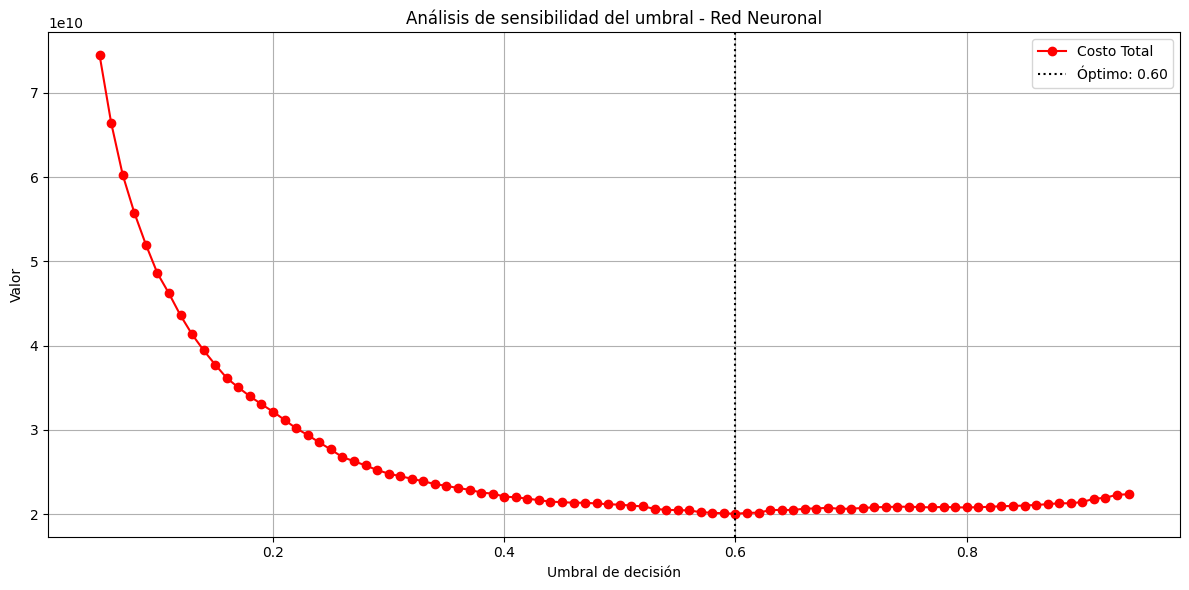

In [ ]:
# Encontrar umbral óptimo
idx_min_nn = np.argmin(costos_nn)
mejor_umbral_nn = umbrales[idx_min_nn]
mejor_costo_nn = costos_nn[idx_min_nn]

plt.figure(figsize=(12, 6))

# Costo
plt.plot(umbrales, costos_nn, 'o-r', label='Costo Total')


# Línea de umbral óptimo
plt.axvline(mejor_umbral_nn, color='black', linestyle=':', label=f'Óptimo: {mejor_umbral_nn:.2f}')

plt.title("Análisis de sensibilidad del umbral - Red Neuronal")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
